# Left-Ventricular Wall Thickness on the CardioSDF 3D Model

This notebook estimates left-ventricular (LV) wall thickness **on the trained CardioSDF/INR 3D model**.

The trained model is used first to generate the endocardial and epicardial 3D surfaces. The ten wall-thickness algorithms are then applied to that model geometry.

Default dataset: `demo-data/training/patient001`, end-diastole (ED frame from `Info.cfg`).

Model geometry source:

| Model | Source |
|---|---|
| CardioSDF/INR neural model | `model/inr_sdf_combined_fresh_ed_mix_v1_final.ptrom` |

Wall-thickness method groups applied to the model:

| Group | Methods |
|---|---|
| Distance / mesh | 1. KD-tree nearest neighbour; 2. symmetric KD-tree |
| Normal / ray | 3. normal rays; 8. cone/SDF rays |
| Volumetric EDT | 4. EDT boundary sum; 5. EDT medial axis |
| PDE / field | 6. Laplace field; 10. Yezzi--Prince |
| Graph / regularization | 7. geodesic Dijkstra; 9. regularized correspondence |

Outputs:

- summary table for the 10 methods on the CardioSDF model
- one 10-panel 3D wall-thickness color-map figure on the model surface
- one AHA-17 bullseye figure for the 10 methods
- AHA anatomical QA figure to verify base/apex direction and septal orientation
- saved figures/tables under `notebooks/outputs`

Install notebook dependencies before running:

```bash
pip install -r requirements-notebook.txt
```

`torch` is required for the trained CardioSDF checkpoint. `pyezzi` is required for Method 10 and intentionally fails clearly if unavailable.

In [ ]:
from __future__ import annotations

import importlib
import json
import math
import os
import sys
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import patches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from scipy import ndimage, sparse
from scipy.ndimage import distance_transform_edt, maximum_filter
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import dijkstra
from scipy.sparse import linalg as spla
from skimage import measure
import torch
import trimesh

# Notebook paths
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = Path("/home/andre/Downloads/tese/webapp").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.nifti import load_nifti, resolve_nifti_path
from core.inference import analyse_segmentation
from core.sdf_model import (
    FLIP_Z as CARDIOSDF_FLIP_Z,
    extract_contours as extract_cardiosdf_contours,
    load_model as load_cardiosdf_model,
    predict_sdf_meshes as predict_cardiosdf_meshes,
)

# Segmentation labels used by ACDC and this webapp.
LBL_BG, LBL_RV, LBL_MYO, LBL_LV = 0, 1, 2, 3

DATA_ROOT = PROJECT_ROOT / "demo-data" / "training"
CASE_ID = "patient001"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = PROJECT_ROOT / "model" / "inr_sdf_combined_fresh_ed_mix_v1_final.ptrom"
CARDIOSDF_GRID_RES = int(os.environ.get("CARDIOSDF_GRID_RES", "72"))

CMIN_MM = 3.0
CMAX_MM = 15.0
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Required package check. torch is required for the trained CardioSDF/INR checkpoint;
# pyezzi is intentionally required because Method 10 is not replaced silently.
REQUIRED_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "skimage": "skimage",
    "trimesh": "trimesh",
    "torch": "torch",
    "pyezzi": "pyezzi",
}
missing = []
for package_name, import_name in REQUIRED_IMPORTS.items():
    try:
        importlib.import_module(import_name)
    except Exception as exc:
        missing.append(f"{package_name}: {exc}")
if missing:
    raise ImportError(
        "Missing notebook dependencies. Install them with `pip install -r requirements-notebook.txt`.\n"
        + "\n".join(missing)
    )

try:
    from pyezzi import compute_thickness_cardiac
except Exception as exc:
    raise ImportError(
        "Method 10 requires `pyezzi`. Install notebook dependencies with "
        "`pip install -r requirements-notebook.txt`."
    ) from exc

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"CardioSDF checkpoint not found: {MODEL_PATH}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")
print(f"CardioSDF checkpoint: {MODEL_PATH}")
print(f"CardioSDF grid resolution: {CARDIOSDF_GRID_RES}")

Project root: /home/andre/Downloads/tese/webapp
Outputs: /home/andre/Downloads/tese/webapp/notebooks/outputs
CardioSDF checkpoint: /home/andre/Downloads/tese/webapp/model/inr_sdf_combined_fresh_ed_mix_v1_final.ptrom
CardioSDF grid resolution: 72


## 1. Load patient001 ED segmentation

The notebook uses the same NIfTI helpers as the webapp. `Info.cfg` is parsed so that `ED: 1` maps to `patient001_frame01_gt.nii`.

In [39]:
def read_info_cfg(path: Path) -> dict[str, str]:
    info: dict[str, str] = {}
    for line in path.read_text().splitlines():
        if ":" in line:
            key, value = line.split(":", 1)
            info[key.strip()] = value.strip()
    return info

case_dir = DATA_ROOT / CASE_ID
info = read_info_cfg(case_dir / "Info.cfg")
ed_frame_1_based = int(info["ED"])
ed_frame = ed_frame_1_based - 1
ed_folder = case_dir / f"{CASE_ID}_frame{ed_frame_1_based:02d}.nii"
ed_seg_folder = case_dir / f"{CASE_ID}_frame{ed_frame_1_based:02d}_gt.nii"

mri = load_nifti(ed_folder)
seg_nifti = load_nifti(ed_seg_folder)
seg = np.rint(seg_nifti["data"]).astype(np.int16)
spacing = tuple(float(v) for v in seg_nifti["zooms"])
affine = seg_nifti["affine"]

lv_mask = seg == LBL_LV
myo_mask = seg == LBL_MYO
rv_mask = seg == LBL_RV
epi_mask = lv_mask | myo_mask
support_slices = np.flatnonzero(epi_mask.any(axis=(0, 1)))

assert seg.ndim == 3, f"Expected a 3D ED segmentation, got shape {seg.shape}"
assert lv_mask.any(), "No LV cavity label found. Expected ACDC LV label 3."
assert myo_mask.any(), "No myocardium label found. Expected ACDC MYO label 2."

label_counts = pd.Series({
    "background": int((seg == LBL_BG).sum()),
    "rv": int(rv_mask.sum()),
    "myocardium": int(myo_mask.sum()),
    "lv_cavity": int(lv_mask.sum()),
})

display(pd.DataFrame({
    "value": {
        "case": CASE_ID,
        "ED frame (1-based)": ed_frame_1_based,
        "seg shape": seg.shape,
        "spacing_mm": spacing,
        "support slices": support_slices.tolist(),
        "mri path": mri["path"],
        "seg path": seg_nifti["path"],
    }
}))
display(label_counts.to_frame("voxel_count"))

,value
case,patient077
ED frame (1-based),1
seg shape,"(214, 256, 8)"
spacing_mm,"(1.40625, 1.40625, 10.0)"
support slices,"[0, 1, 2, 3, 4, 5, 6, 7]"
mri path,/home/andre/Downloads/tese/webapp/demo-data/tr...
seg path,/home/andre/Downloads/tese/webapp/demo-data/tr...


,voxel_count
background,418609
rv,8159
myocardium,4680
lv_cavity,6824


## 2. Generate the CardioSDF model geometry and shared helpers

The input segmentation is used only to extract contour rings for the trained model and to orient AHA-17 anatomy. The analysis mesh (`P`, `Q`, `F`) and volumetric masks used by the ten methods are generated from the CardioSDF/INR model itself.

In [40]:
@dataclass
class MethodResult:
    name: str
    group: str
    values: np.ndarray
    runtime_s: float
    valid_fraction: float
    warnings: list[str] = field(default_factory=list)
    diagnostics: dict[str, Any] = field(default_factory=dict)
    volume_field: np.ndarray | None = None


def finite_fraction(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    return float(np.isfinite(values).mean()) if values.size else 0.0


def summarize_values(values: np.ndarray) -> dict[str, float | int | None]:
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {"n": 0, "mean_mm": None, "median_mm": None, "std_mm": None, "p5_mm": None, "p95_mm": None, "min_mm": None, "max_mm": None}
    return {
        "n": int(vals.size),
        "mean_mm": round(float(vals.mean()), 3),
        "median_mm": round(float(np.median(vals)), 3),
        "std_mm": round(float(vals.std()), 3),
        "p5_mm": round(float(np.percentile(vals, 5)), 3),
        "p95_mm": round(float(np.percentile(vals, 95)), 3),
        "min_mm": round(float(vals.min()), 3),
        "max_mm": round(float(vals.max()), 3),
    }


def timed_result(name: str, group: str, fn: Callable[[], tuple[np.ndarray, dict[str, Any], list[str], np.ndarray | None]]) -> MethodResult:
    start = time.perf_counter()
    values, diagnostics, warn, volume = fn()
    runtime_s = time.perf_counter() - start
    values = np.asarray(values, dtype=np.float32)
    return MethodResult(name, group, values, runtime_s, finite_fraction(values), warn, diagnostics, volume)


def _clean_mesh_faces(mesh: trimesh.Trimesh) -> trimesh.Trimesh:
    if hasattr(mesh, "nondegenerate_faces"):
        mesh.update_faces(mesh.nondegenerate_faces())
    elif hasattr(mesh, "remove_degenerate_faces"):
        mesh.remove_degenerate_faces()
    if hasattr(mesh, "unique_faces"):
        mesh.update_faces(mesh.unique_faces())
    elif hasattr(mesh, "remove_duplicate_faces"):
        mesh.remove_duplicate_faces()
    mesh.remove_unreferenced_vertices()
    return mesh


def payload_array(payload: dict[str, Any], key: str, width: int) -> np.ndarray:
    dtype = np.int32 if key == "faces" else np.float32
    arr = np.asarray(payload.get(key, []), dtype=dtype)
    return np.empty((0, width), dtype=dtype) if arr.size == 0 else arr.reshape(-1, width)


def mesh_from_payload(payload: dict[str, Any], name: str) -> trimesh.Trimesh:
    vertices = payload_array(payload, "vertices", 3)
    faces = payload_array(payload, "faces", 3).astype(np.int32)
    if len(vertices) == 0 or len(faces) == 0:
        raise ValueError(f"CardioSDF returned an empty {name} mesh.")
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)
    mesh = _clean_mesh_faces(mesh)
    try:
        trimesh.repair.fix_normals(mesh)
    except Exception as exc:
        warnings.warn(f"Could not repair normals for {name}: {exc}")
    mesh.metadata["name"] = name
    return mesh


def voxel_to_world(indices: np.ndarray, spacing_mm: tuple[float, float, float]) -> np.ndarray:
    """Convert voxel indices (row, col, slice) to world coords matching extract_contours.

    extract_contours uses: vox=[col, row, 0, 1]; world = affine @ vox; world[:,2] = s*dz.
    With the ACDC affine = diag(-1,-1,1), this gives x=-col, y=-row, z=slice*dz.
    """
    indices = np.asarray(indices, dtype=np.float32)
    pts = np.empty((len(indices), 3), dtype=np.float32)
    pts[:, 0] = -indices[:, 1]  # x = -col (affine[0,0] = -1)
    pts[:, 1] = -indices[:, 0]  # y = -row (affine[1,1] = -1)
    pts[:, 2] = indices[:, 2] * spacing_mm[2]  # z = slice * dz
    return pts


def orient_normals_toward_epicardium(endo_mesh: trimesh.Trimesh, epi_vertices: np.ndarray) -> tuple[np.ndarray, dict[str, Any]]:
    points = np.asarray(endo_mesh.vertices, dtype=np.float32)
    normals = np.asarray(endo_mesh.vertex_normals, dtype=np.float32).copy()
    distances, nn = cKDTree(epi_vertices).query(points, workers=-1)
    vectors = epi_vertices[nn] - points
    dots = np.sum(normals * vectors, axis=1)
    median_dot = float(np.nanmedian(dots))
    flipped = False
    if median_dot < 0:
        normals *= -1.0
        flipped = True
        dots = -dots
    return normals, {
        "median_normal_to_epi_dot": median_dot,
        "normals_flipped": flipped,
        "median_nearest_epi_distance_mm": float(np.nanmedian(distances)),
        "negative_dot_fraction_after_orient": float((dots < 0).mean()),
    }


def sample_myo_field_at_vertices(field: np.ndarray, vertices: np.ndarray, myo_idx: np.ndarray, myo_tree: cKDTree) -> np.ndarray:
    _, nn = myo_tree.query(vertices, workers=-1)
    idx = myo_idx[nn]
    return np.asarray(field[idx[:, 0], idx[:, 1], idx[:, 2]], dtype=np.float32)


def fill_invalid_from_nearest(points: np.ndarray, values: np.ndarray) -> np.ndarray:
    out = np.asarray(values, dtype=np.float32).copy()
    valid = np.isfinite(out)
    if valid.all() or not valid.any():
        return out
    _, nn = cKDTree(points[valid]).query(points[~valid], workers=-1)
    out[~valid] = out[valid][nn]
    return out


def contour_tensor_for_model(model: Any, contours: dict[str, Any], cfg: dict, phase_val: float | None = 0.0) -> tuple[torch.Tensor, torch.Tensor]:
    cont = np.column_stack([contours["xyz"], contours["tissue"]]).astype(np.float32)
    if phase_val is not None and cfg.get("input_dim", 4) == 5:
        cont = np.column_stack([cont, np.full((len(cont), 1), phase_val, dtype=np.float32)])
    device = next(model.parameters()).device
    cont_t = torch.from_numpy(cont).unsqueeze(0).to(device)
    mask_t = torch.ones(1, len(cont), dtype=torch.bool, device=device)
    return cont_t, mask_t


def evaluate_cardiosdf_native_grid(model: Any, cfg: dict, contours: dict[str, Any], grid_res: int, batch_size: int = 131072) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    cont_t, mask_t = contour_tensor_for_model(model, contours, cfg, phase_val=0.0)
    with torch.no_grad():
        z = model.encode(cont_t, mask_t)
    bbox_pad = cfg.get("bbox_pad", 0.3)
    lo = contours["xyz"].min(axis=0) - bbox_pad
    hi = contours["xyz"].max(axis=0) + bbox_pad
    xs = np.linspace(lo[0], hi[0], grid_res)
    ys = np.linspace(lo[1], hi[1], grid_res)
    zs = np.linspace(lo[2], hi[2], grid_res)
    gx, gy, gz = np.meshgrid(xs, ys, zs, indexing="ij")
    query = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=-1).astype(np.float32)
    f_endo = np.empty(len(query), dtype=np.float32)
    f_epi = np.empty(len(query), dtype=np.float32)
    device = next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(query), batch_size):
            chunk_np = query[start:start + batch_size]
            chunk = torch.from_numpy(chunk_np).unsqueeze(0).to(device)
            fe, fp, _ = model.decode(z, chunk)
            f_endo[start:start + len(chunk_np)] = fe[0].detach().cpu().numpy().astype(np.float32)
            f_epi[start:start + len(chunk_np)] = fp[0].detach().cpu().numpy().astype(np.float32)
    shape = (grid_res, grid_res, grid_res)
    voxel_norm = (hi - lo) / (grid_res - 1)
    return f_endo.reshape(shape), f_epi.reshape(shape), lo.astype(np.float32), voxel_norm.astype(np.float32)


def cardiosdf_grid_indices_to_world(indices: np.ndarray, lo: np.ndarray, voxel_norm: np.ndarray, contours: dict[str, Any]) -> np.ndarray:
    norm_xyz = lo[None, :] + indices.astype(np.float32) * voxel_norm[None, :]
    flip = np.array([1.0, 1.0, -1.0 if CARDIOSDF_FLIP_Z else 1.0], dtype=np.float32)
    return norm_xyz * flip[None, :] * float(contours["scale"]) + contours["centroid"][None, :]


def masks_from_cardiosdf_fields(f_endo: np.ndarray, f_epi: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, Any]]:
    candidates = []
    for endo_less in (True, False):
        for epi_less in (True, False):
            cand_lv = f_endo <= 0 if endo_less else f_endo >= 0
            cand_epi = f_epi <= 0 if epi_less else f_epi >= 0
            myo = cand_epi & ~cand_lv
            if cand_lv.sum() == 0 or cand_epi.sum() == 0 or myo.sum() == 0:
                continue
            subset_fraction = float(np.logical_and(cand_lv, cand_epi).sum() / max(cand_lv.sum(), 1))
            score = subset_fraction + 0.01 * math.log1p(int(myo.sum())) - 0.001 * abs(int(cand_epi.sum()) - int(cand_lv.sum())) / max(cand_epi.size, 1)
            candidates.append((score, endo_less, epi_less, cand_lv, cand_epi, myo, subset_fraction))
    if not candidates:
        cand_lv = f_endo <= 0
        cand_epi = f_epi <= 0
        myo = cand_epi & ~cand_lv
        if myo.sum() == 0:
            raise RuntimeError("Could not derive a non-empty myocardium from the CardioSDF fields.")
        selected = (float("nan"), True, True, cand_lv, cand_epi, myo, float(np.logical_and(cand_lv, cand_epi).sum() / max(cand_lv.sum(), 1)))
    else:
        selected = max(candidates, key=lambda x: x[0])
    score, endo_less, epi_less, cand_lv, cand_epi, myo, subset_fraction = selected
    diag = {
        "selected_endo_inside": "f_endo <= 0" if endo_less else "f_endo >= 0",
        "selected_epi_inside": "f_epi <= 0" if epi_less else "f_epi >= 0",
        "sign_selection_score": None if not np.isfinite(score) else float(score),
        "endo_subset_of_epi_fraction": subset_fraction,
        "model_lv_voxels": int(cand_lv.sum()),
        "model_epi_voxels": int(cand_epi.sum()),
        "model_myo_voxels": int(myo.sum()),
    }
    return cand_lv.astype(bool), cand_epi.astype(bool), myo.astype(bool), diag


# The original segmentation remains available as input/reference. The analysis geometry below is generated by the trained model.
gt_lv_mask = lv_mask.copy()
gt_myo_mask = myo_mask.copy()
gt_epi_mask = epi_mask.copy()
analysis_geometry_source = "CardioSDF/INR model checkpoint"

cardiosdf_contours = extract_cardiosdf_contours(seg, affine, spacing[2])
cardiosdf_model, cardiosdf_cfg = load_cardiosdf_model(MODEL_PATH)
cardiosdf_output = predict_cardiosdf_meshes(
    cardiosdf_model,
    cardiosdf_contours["xyz"],
    cardiosdf_contours["tissue"],
    cardiosdf_cfg,
    grid_res=CARDIOSDF_GRID_RES,
    phase_val=0.0,
    scale=cardiosdf_contours["scale"],
    centroid=cardiosdf_contours["centroid"],
    seg_volume=seg,
    spacing=spacing,
)

# These are the CardioSDF model-generated 3D surfaces used by every method.
endo_mesh = mesh_from_payload(cardiosdf_output["meshes"]["endo"], "CardioSDF endocardium")
epi_mesh = mesh_from_payload(cardiosdf_output["meshes"]["epi"], "CardioSDF epicardium")
P = np.asarray(endo_mesh.vertices, dtype=np.float32)
Q = np.asarray(epi_mesh.vertices, dtype=np.float32)
F = np.asarray(endo_mesh.faces, dtype=np.int32)

# These are CardioSDF model-derived volumetric masks on the model's own SDF grid, used only by volumetric methods.
f_endo_grid, f_epi_grid, cardiosdf_grid_lo, cardiosdf_grid_voxel_norm = evaluate_cardiosdf_native_grid(
    cardiosdf_model, cardiosdf_cfg, cardiosdf_contours, CARDIOSDF_GRID_RES
)
lv_mask, epi_mask, myo_mask, cardiosdf_mask_diag = masks_from_cardiosdf_fields(f_endo_grid, f_epi_grid)
volume_spacing = tuple(float(abs(v) * float(cardiosdf_contours["scale"])) for v in cardiosdf_grid_voxel_norm)
myo_idx = np.argwhere(myo_mask).astype(np.int64)
myo_xyz = cardiosdf_grid_indices_to_world(myo_idx, cardiosdf_grid_lo, cardiosdf_grid_voxel_norm, cardiosdf_contours)
myo_tree = cKDTree(myo_xyz)
endo_normals, normal_diag = orient_normals_toward_epicardium(endo_mesh, Q)

# ── Denormalization sanity check ──
# Compare model extent with segmentation contours to verify correct scale
_seg_lv_indices = np.argwhere(gt_lv_mask)
_seg_lv_world = voxel_to_world(_seg_lv_indices, spacing)
_model_z_extent = float(P[:, 2].max() - P[:, 2].min())
_seg_z_extent = float(_seg_lv_world[:, 2].max() - _seg_lv_world[:, 2].min())
print(f"Denormalization check:")
print(f"  Model endo Z extent: {_model_z_extent:.1f} (units of extract_contours world space)")
print(f"  Segmentation LV Z extent: {_seg_z_extent:.1f} mm")
print(f"  Z ratio (model/seg): {_model_z_extent / _seg_z_extent:.3f}")
print(f"  Model centroid: ({P[:,0].mean():.1f}, {P[:,1].mean():.1f}, {P[:,2].mean():.1f})")
print(f"  Segmentation LV centroid: ({_seg_lv_world[:,0].mean():.1f}, {_seg_lv_world[:,1].mean():.1f}, {_seg_lv_world[:,2].mean():.1f})")
print(f"  Scale factor: {cardiosdf_contours['scale']:.3f}")
# Verify base (larger radius) is at low z for both:
_low_z_mask = P[:, 2] < np.percentile(P[:, 2], 25)
_high_z_mask = P[:, 2] > np.percentile(P[:, 2], 75)
_low_z_r = float(np.sqrt(((P[_low_z_mask, :2] - P[_low_z_mask, :2].mean(0))**2).sum(1)).mean())
_high_z_r = float(np.sqrt(((P[_high_z_mask, :2] - P[_high_z_mask, :2].mean(0))**2).sum(1)).mean())
print(f"  Model base (low-z) mean radius: {_low_z_r:.2f}, apex (high-z) mean radius: {_high_z_r:.2f}")
assert _low_z_r > _high_z_r, "Base should have larger radius than apex!"
print("  ✓ Base at low z, apex at high z — orientation correct.")

mesh_quality = pd.DataFrame({
    "metric": [
        "analysis geometry source", "checkpoint", "native mean WT mm", "model grid res", "volume spacing mm",
        "endo vertices", "endo faces", "epi vertices", "epi faces", "endo watertight", "epi watertight",
        "model LV voxels", "model MYO voxels", "model EPI voxels", "endo subset epi fraction",
        "endo area cm2", "epi area cm2", "normals flipped", "negative dot fraction",
    ],
    "value": [
        analysis_geometry_source, str(MODEL_PATH), cardiosdf_output["metrics"].get("meanWallThicknessMm"), CARDIOSDF_GRID_RES, tuple(round(v, 3) for v in volume_spacing),
        len(P), len(F), len(Q), len(epi_mesh.faces), bool(endo_mesh.is_watertight), bool(epi_mesh.is_watertight),
        cardiosdf_mask_diag["model_lv_voxels"], cardiosdf_mask_diag["model_myo_voxels"], cardiosdf_mask_diag["model_epi_voxels"], round(cardiosdf_mask_diag["endo_subset_of_epi_fraction"], 4),
        round(float(endo_mesh.area) / 100.0, 3), round(float(epi_mesh.area) / 100.0, 3),
        normal_diag["normals_flipped"], round(normal_diag["negative_dot_fraction_after_orient"], 4),
    ],
})
display(mesh_quality)
print("All ten methods below use the CardioSDF-generated endocardial/epicardial model, not a segmentation marching-cubes mesh.")

Denormalization check:
  Model endo Z extent: 73.5 (units of extract_contours world space)
  Segmentation LV Z extent: 70.0 mm
  Z ratio (model/seg): 1.050
  Model centroid: (-133.1, -104.3, 27.1)
  Segmentation LV centroid: (-133.3, -104.6, 23.3)
  Scale factor: 17.982
  Model base (low-z) mean radius: 19.15, apex (high-z) mean radius: 10.40
  ✓ Base at low z, apex at high z — orientation correct.


,metric,value
0,analysis geometry source,CardioSDF/INR model checkpoint
1,checkpoint,/home/andre/Downloads/tese/webapp/model/inr_sd...
2,native mean WT mm,4.54
3,model grid res,72
4,volume spacing mm,"(0.961, 0.898, 1.138)"
5,endo vertices,13053
6,endo faces,25578
7,epi vertices,17731
8,epi faces,17343
9,endo watertight,False


All ten methods below use the CardioSDF-generated endocardial/epicardial model, not a segmentation marching-cubes mesh.


## 3. AHA-17 segmentation with anatomical QA

The AHA assignment below deliberately detects the base-to-apex direction from the segmentation support and LV slice areas. This avoids blindly assuming that raw z increases from base to apex.

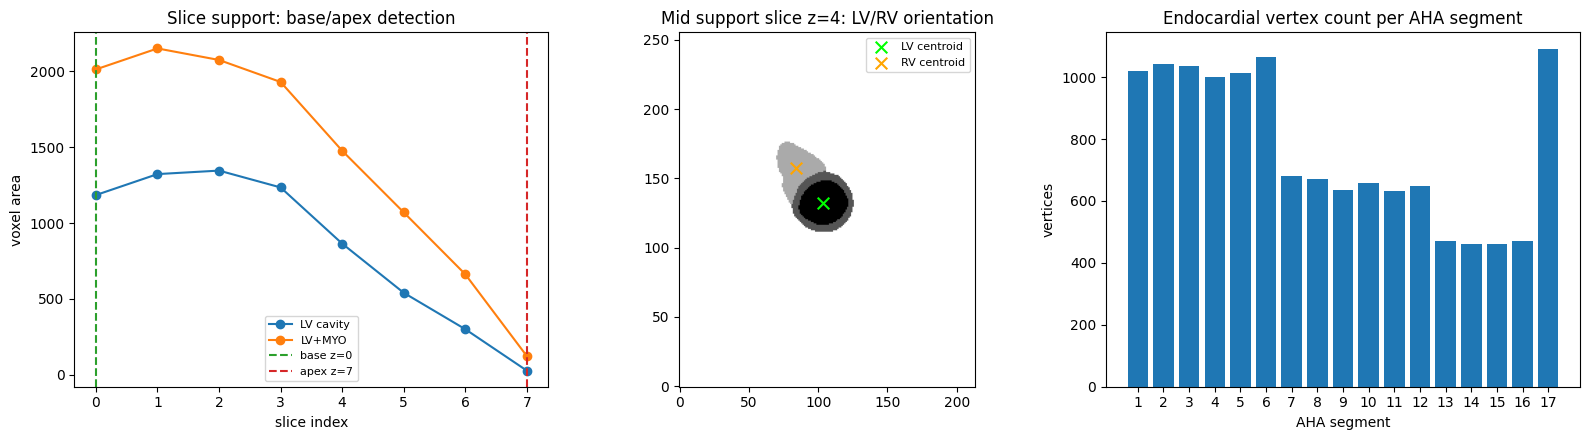

Saved AHA anatomical QA figure to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_aha_anatomy_qa.png


,diagnostic,value
0,support_slices,[0 1 2 3 4 5 6 7]
1,lv_area,[1185. 1323. 1346. 1235. 865. 541. 301. 28.]
2,epi_area,[2013. 2151. 2075. 1930. 1477. 1071. 663. 124.]
3,base_slice,0
4,apex_slice,7
5,base_z_mm,0.0
6,apex_z_mm,70.0
7,z_sign_base_to_apex,1.0
8,first_end_score,1688.25
9,last_end_score,59.0


In [41]:
AHA_17_NAMES = [
    "Basal Anterior", "Basal Anteroseptal", "Basal Inferoseptal",
    "Basal Inferior", "Basal Inferolateral", "Basal Anterolateral",
    "Mid Anterior", "Mid Anteroseptal", "Mid Inferoseptal",
    "Mid Inferior", "Mid Inferolateral", "Mid Anterolateral",
    "Apical Anterior", "Apical Septal", "Apical Inferior", "Apical Lateral",
    "Apex",
]


def detect_base_apex(seg_volume: np.ndarray, spacing_mm: tuple[float, float, float]) -> dict[str, Any]:
    labels = np.rint(seg_volume).astype(np.int16)
    lv = labels == LBL_LV
    epi = (labels == LBL_LV) | (labels == LBL_MYO)
    support = np.flatnonzero(epi.any(axis=(0, 1)))
    if support.size < 2:
        raise ValueError("Need at least two supported slices to determine base/apex direction.")
    lv_area = lv.sum(axis=(0, 1)).astype(float)
    epi_area = epi.sum(axis=(0, 1)).astype(float)
    first = int(support[0])
    last = int(support[-1])
    first_score = float(lv_area[first] + 0.25 * epi_area[first])
    last_score = float(lv_area[last] + 0.25 * epi_area[last])
    if first_score >= last_score:
        base_slice, apex_slice, z_sign = first, last, 1.0
    else:
        base_slice, apex_slice, z_sign = last, first, -1.0
    base_z = base_slice * spacing_mm[2]
    apex_z = apex_slice * spacing_mm[2]
    return {
        "support_slices": support,
        "lv_area": lv_area,
        "epi_area": epi_area,
        "base_slice": base_slice,
        "apex_slice": apex_slice,
        "base_z_mm": float(base_z),
        "apex_z_mm": float(apex_z),
        "z_sign_base_to_apex": z_sign,
        "first_end_score": first_score,
        "last_end_score": last_score,
    }


def assign_aha17_segments(
    vertices: np.ndarray,
    seg_volume: np.ndarray,
    spacing_mm: tuple[float, float, float],
    apical_end: float = 0.85,
) -> tuple[np.ndarray, dict[str, Any]]:
    diag = detect_base_apex(seg_volume, spacing_mm)
    labels = np.rint(seg_volume).astype(np.int16)
    vertices = np.asarray(vertices, dtype=np.float32)

    base_z = diag["base_z_mm"]
    apex_z = diag["apex_z_mm"]
    denom = apex_z - base_z
    if abs(denom) < 1e-6:
        raise ValueError("Base and apex z positions are too close to assign AHA levels.")
    z_base_to_apex = np.clip((vertices[:, 2] - base_z) / denom, 0.0, 1.0)

    cx = float(vertices[:, 0].mean())
    cy = float(vertices[:, 1].mean())
    rv_centroid_xy = None
    anterior_angle = 0.0
    septal_angle = None
    rv_mask_local = labels == LBL_RV
    if rv_mask_local.any():
        rv_pts = voxel_to_world(np.argwhere(rv_mask_local), spacing_mm)
        rv_centroid_xy = rv_pts[:, :2].mean(axis=0)
        septal_angle = math.atan2(float(rv_centroid_xy[1] - cy), float(rv_centroid_xy[0] - cx))
        # Same convention used by the webapp: LV->RV is septal; anterior is 90 degrees from septal.
        anterior_angle = septal_angle - math.pi / 2.0

    raw_angles = np.arctan2(vertices[:, 1] - cy, vertices[:, 0] - cx)
    angles_deg = np.degrees(raw_angles - anterior_angle) % 360.0

    segment_ids = np.full(len(vertices), 17, dtype=np.int16)
    basal = z_base_to_apex < (1.0 / 3.0)
    mid = (z_base_to_apex >= (1.0 / 3.0)) & (z_base_to_apex < (2.0 / 3.0))
    apical = (z_base_to_apex >= (2.0 / 3.0)) & (z_base_to_apex < apical_end)

    seg6 = (angles_deg / 60.0).astype(np.int16) % 6
    seg4 = (angles_deg / 90.0).astype(np.int16) % 4
    segment_ids[basal] = 1 + seg6[basal]
    segment_ids[mid] = 7 + seg6[mid]
    segment_ids[apical] = 13 + seg4[apical]

    counts = {int(i): int((segment_ids == i).sum()) for i in range(1, 18)}
    rv_angle_from_anterior = None
    if septal_angle is not None:
        rv_angle_from_anterior = float(np.degrees(septal_angle - anterior_angle) % 360.0)
    diag.update({
        "lv_centroid_xy_mm": (cx, cy),
        "rv_centroid_xy_mm": None if rv_centroid_xy is None else tuple(float(v) for v in rv_centroid_xy),
        "anterior_angle_deg": float(np.degrees(anterior_angle) % 360.0),
        "rv_angle_from_anterior_deg": rv_angle_from_anterior,
        "segment_counts": counts,
        "z_base_to_apex_minmax": (float(z_base_to_apex.min()), float(z_base_to_apex.max())),
        "apical_end_threshold": apical_end,
    })
    return segment_ids, diag


def aha_stats_from_values(values: np.ndarray, segment_ids: np.ndarray) -> pd.DataFrame:
    rows = []
    for seg_id, name in enumerate(AHA_17_NAMES, start=1):
        vals = np.asarray(values)[segment_ids == seg_id]
        vals = vals[np.isfinite(vals)]
        rows.append({
            "id": seg_id,
            "name": name,
            "n": int(vals.size),
            "meanMm": float(vals.mean()) if vals.size else np.nan,
            "p95Mm": float(np.percentile(vals, 95)) if vals.size else np.nan,
        })
    return pd.DataFrame(rows)


def plot_aha_anatomy_qa(
    seg_volume: np.ndarray,
    spacing_mm: tuple[float, float, float],
    segment_ids: np.ndarray,
    diag: dict[str, Any],
    save_path: Path | None = None,
) -> Path | None:
    labels = np.rint(seg_volume).astype(np.int16)
    support = diag["support_slices"]
    lv_area = diag["lv_area"]
    epi_area = diag["epi_area"]
    base_slice = diag["base_slice"]
    apex_slice = diag["apex_slice"]
    mid_slice = int(support[len(support) // 2])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ax = axes[0]
    ax.plot(support, lv_area[support], "o-", label="LV cavity")
    ax.plot(support, epi_area[support], "o-", label="LV+MYO")
    ax.axvline(base_slice, color="tab:green", linestyle="--", label=f"base z={base_slice}")
    ax.axvline(apex_slice, color="tab:red", linestyle="--", label=f"apex z={apex_slice}")
    ax.set_title("Slice support: base/apex detection")
    ax.set_xlabel("slice index")
    ax.set_ylabel("voxel area")
    ax.legend(fontsize=8)

    ax = axes[1]
    sl = labels[:, :, mid_slice].T
    ax.imshow(sl, origin="lower", cmap="gray_r")
    lv_pts = np.argwhere(labels[:, :, mid_slice] == LBL_LV)
    rv_pts = np.argwhere(labels[:, :, mid_slice] == LBL_RV)
    if len(lv_pts):
        ax.scatter(lv_pts[:, 0].mean(), lv_pts[:, 1].mean(), s=70, c="lime", marker="x", label="LV centroid")
    if len(rv_pts):
        ax.scatter(rv_pts[:, 0].mean(), rv_pts[:, 1].mean(), s=70, c="orange", marker="x", label="RV centroid")
    ax.set_title(f"Mid support slice z={mid_slice}: LV/RV orientation")
    ax.legend(fontsize=8)

    ax = axes[2]
    counts = np.array([diag["segment_counts"][i] for i in range(1, 18)])
    ax.bar(np.arange(1, 18), counts)
    ax.set_title("Endocardial vertex count per AHA segment")
    ax.set_xlabel("AHA segment")
    ax.set_ylabel("vertices")
    ax.set_xticks(np.arange(1, 18))
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=250, bbox_inches="tight")
    plt.show()
    return save_path


aha_segment_ids, aha_diag = assign_aha17_segments(P, seg, spacing)
aha_qa_path = plot_aha_anatomy_qa(
    seg,
    spacing,
    aha_segment_ids,
    aha_diag,
    save_path=OUTPUT_DIR / "lv_wall_thickness_aha_anatomy_qa.png",
)
if aha_qa_path:
    print(f"Saved AHA anatomical QA figure to {aha_qa_path}")

pd.DataFrame({
    "diagnostic": list(aha_diag.keys()),
    "value": [str(v) for v in aha_diag.values()],
})

## 4. Implement the 10 wall-thickness methods

Each function returns per-endocardial-vertex thickness in millimetres. Methods that operate on voxels first project the resulting field to the nearest myocardium voxel for each endocardial vertex.

In [42]:
RAY_SAMPLE_LIMIT = int(os.environ.get("CARDIOSDF_RAY_SAMPLE_LIMIT", "6000"))
CONE_RAY_SAMPLE_LIMIT = int(os.environ.get("CARDIOSDF_CONE_RAY_SAMPLE_LIMIT", "1800"))
CONE_RAY_COUNT = int(os.environ.get("CARDIOSDF_CONE_RAY_COUNT", "7"))
RAY_CHUNK_SIZE = int(os.environ.get("CARDIOSDF_RAY_CHUNK_SIZE", "1024"))


def evenly_spaced_indices(n: int, limit: int) -> np.ndarray:
    if n <= limit:
        return np.arange(n, dtype=np.int64)
    return np.unique(np.linspace(0, n - 1, limit, dtype=np.int64))


def fill_from_sampled_vertices(sample_idx: np.ndarray, sample_values: np.ndarray, fallback: np.ndarray | None = None) -> tuple[np.ndarray, dict[str, Any], list[str]]:
    values = np.full(len(P), np.nan, dtype=np.float32)
    sample_values = np.asarray(sample_values, dtype=np.float32)
    valid = np.isfinite(sample_values)
    warnings_out: list[str] = []
    if valid.any():
        values[sample_idx[valid]] = sample_values[valid]
        values = fill_invalid_from_nearest(P, values)
    else:
        if fallback is None:
            fallback, _ = cKDTree(Q).query(P, workers=-1)
        values = np.asarray(fallback, dtype=np.float32)
        warnings_out.append("No valid ray intersections were found; returned KD-tree fallback values.")
    diagnostics = {
        "sampled_vertices": int(len(sample_idx)),
        "sample_fraction": float(len(sample_idx) / len(P)),
        "sample_valid_fraction": float(valid.mean()) if len(valid) else 0.0,
        "filled_from_nearest_sample": bool(valid.any() and len(sample_idx) < len(P)),
    }
    return values.astype(np.float32), diagnostics, warnings_out


def method_kdtree() -> tuple[np.ndarray, dict[str, Any], list[str], None]:
    distances, nn = cKDTree(Q).query(P, workers=-1)
    diagnostics = {"nearest_epi_vertex_index_shape": nn.shape}
    return distances.astype(np.float32), diagnostics, [], None


def method_symmetric_kdtree() -> tuple[np.ndarray, dict[str, Any], list[str], None]:
    tree_epi = cKDTree(Q)
    tree_endo = cKDTree(P)
    endo_to_epi, endo_epi_idx = tree_epi.query(P, workers=-1)
    epi_to_endo, _ = tree_endo.query(Q, workers=-1)
    reverse_on_endo = epi_to_endo[endo_epi_idx]
    symmetric = 0.5 * (endo_to_epi + reverse_on_endo)
    diagnostics = {
        "mean_endo_to_epi_mm": float(np.nanmean(endo_to_epi)),
        "mean_epi_to_endo_mm": float(np.nanmean(epi_to_endo)),
        "symmetry_delta_mm": float(abs(np.nanmean(endo_to_epi) - np.nanmean(epi_to_endo))),
    }
    warnings_out = []
    if diagnostics["symmetry_delta_mm"] > 1.0:
        warnings_out.append("Large endo/epi symmetry delta; inspect mesh quality or anatomy at apex.")
    return symmetric.astype(np.float32), diagnostics, warnings_out, None


def ray_intersection_distances(
    origins: np.ndarray,
    directions: np.ndarray,
    epi: trimesh.Trimesh,
    max_distance_mm: float | None = None,
    chunk_size: int = RAY_CHUNK_SIZE,
) -> np.ndarray:
    directions = np.asarray(directions, dtype=np.float64)
    origins = np.asarray(origins, dtype=np.float64)
    directions /= np.linalg.norm(directions, axis=1, keepdims=True).clip(min=1e-12)
    intersector = trimesh.ray.ray_triangle.RayMeshIntersector(epi)
    distances = np.full(len(origins), np.nan, dtype=np.float32)
    for start in range(0, len(origins), chunk_size):
        stop = min(start + chunk_size, len(origins))
        locations, index_ray, _ = intersector.intersects_location(
            ray_origins=origins[start:stop],
            ray_directions=directions[start:stop],
            multiple_hits=False,
        )
        if not len(locations):
            continue
        d = np.linalg.norm(locations - origins[start:stop][index_ray], axis=1)
        for loc_dist, local_ray_idx in zip(d, index_ray):
            ray_idx = start + int(local_ray_idx)
            if loc_dist <= 1e-6:
                continue
            if max_distance_mm is not None and loc_dist > max_distance_mm:
                continue
            old = distances[ray_idx]
            if not np.isfinite(old) or loc_dist < old:
                distances[ray_idx] = loc_dist
    return distances


def method_normal_rays() -> tuple[np.ndarray, dict[str, Any], list[str], None]:
    sample_idx = evenly_spaced_indices(len(P), RAY_SAMPLE_LIMIT)
    raw_sample = ray_intersection_distances(P[sample_idx], endo_normals[sample_idx], epi_mesh)
    fallback, _ = cKDTree(Q).query(P, workers=-1)
    values, diagnostics, warnings_out = fill_from_sampled_vertices(sample_idx, raw_sample, fallback=fallback)
    raw_miss_fraction = float((~np.isfinite(raw_sample)).mean()) if len(raw_sample) else 1.0
    diagnostics.update({"raw_miss_fraction": raw_miss_fraction, "ray_chunk_size": RAY_CHUNK_SIZE})
    if raw_miss_fraction > 0.05:
        warnings_out.append(f"Raw normal-ray miss fraction is {raw_miss_fraction:.1%}; missing vertices were filled from nearest valid model vertices.")
    if len(sample_idx) < len(P):
        warnings_out.append(f"Normal rays were evaluated on {len(sample_idx):,}/{len(P):,} model vertices for runtime; the field was interpolated over the full CardioSDF surface.")
    return values, diagnostics, warnings_out, None


def cone_rays(normal: np.ndarray, k: int = CONE_RAY_COUNT, alpha_deg: float = 30.0) -> np.ndarray:
    normal = np.asarray(normal, dtype=np.float64)
    normal /= max(np.linalg.norm(normal), 1e-12)
    alpha = math.radians(alpha_deg)
    ref = np.array([1.0, 0.0, 0.0]) if abs(normal[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(normal, ref)
    u /= max(np.linalg.norm(u), 1e-12)
    v = np.cross(normal, u)
    phi = np.linspace(0.0, 2.0 * math.pi, k, endpoint=False)
    dirs = (
        normal[None, :] * math.cos(alpha)
        + np.cos(phi)[:, None] * u[None, :] * math.sin(alpha)
        + np.sin(phi)[:, None] * v[None, :] * math.sin(alpha)
    )
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True).clip(min=1e-12)
    return np.vstack([normal[None, :], dirs])


def method_sdf_cone_rays(k: int = CONE_RAY_COUNT, alpha_deg: float = 30.0) -> tuple[np.ndarray, dict[str, Any], list[str], None]:
    sample_idx = evenly_spaced_indices(len(P), CONE_RAY_SAMPLE_LIMIT)
    all_origins = []
    all_dirs = []
    owner = []
    for local_i, point_idx in enumerate(sample_idx):
        dirs = cone_rays(endo_normals[point_idx], k=k, alpha_deg=alpha_deg)
        all_origins.append(np.repeat(P[point_idx][None, :], len(dirs), axis=0))
        all_dirs.append(dirs)
        owner.extend([local_i] * len(dirs))
    all_origins_arr = np.vstack(all_origins)
    all_dirs_arr = np.vstack(all_dirs)
    owner_arr = np.asarray(owner, dtype=np.int64)
    hit_dist = ray_intersection_distances(all_origins_arr, all_dirs_arr, epi_mesh)
    sample_values = np.full(len(sample_idx), np.nan, dtype=np.float32)
    for local_i in range(len(sample_idx)):
        vals = hit_dist[owner_arr == local_i]
        vals = vals[np.isfinite(vals)]
        if vals.size:
            sample_values[local_i] = float(np.median(vals))
    fallback, _ = cKDTree(Q).query(P, workers=-1)
    values, diagnostics, warnings_out = fill_from_sampled_vertices(sample_idx, sample_values, fallback=fallback)
    raw_miss_fraction = float((~np.isfinite(sample_values)).mean()) if len(sample_values) else 1.0
    diagnostics.update({
        "raw_miss_fraction": raw_miss_fraction,
        "rays_per_sampled_vertex": int(k + 1),
        "alpha_deg": alpha_deg,
        "total_rays_cast": int(len(all_origins_arr)),
    })
    if raw_miss_fraction > 0.05:
        warnings_out.append(f"Cone-ray miss fraction is {raw_miss_fraction:.1%}; missing values were filled from nearest valid model vertices.")
    if len(sample_idx) < len(P):
        warnings_out.append(f"Cone rays were evaluated on {len(sample_idx):,}/{len(P):,} model vertices for runtime; the field was interpolated over the full CardioSDF surface.")
    return values, diagnostics, warnings_out, None


def _xy_connectivity() -> np.ndarray:
    struct = np.zeros((3, 3, 3), dtype=bool)
    struct[1, 1, 1] = True
    struct[0, 1, 1] = True
    struct[2, 1, 1] = True
    struct[1, 0, 1] = True
    struct[1, 2, 1] = True
    return struct


def boundary_masks(lv: np.ndarray, myo: np.ndarray, epi: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    struct = _xy_connectivity()
    endo_boundary = myo & ndimage.binary_dilation(lv, structure=struct)
    epi_boundary = myo & ndimage.binary_dilation(~epi, structure=struct)
    return endo_boundary, epi_boundary


def method_edt_boundary_sum() -> tuple[np.ndarray, dict[str, Any], list[str], np.ndarray]:
    endo_boundary, epi_boundary = boundary_masks(lv_mask, myo_mask, epi_mask)
    d_endo = distance_transform_edt(~endo_boundary, sampling=volume_spacing)
    d_epi = distance_transform_edt(~epi_boundary, sampling=volume_spacing)
    thickness_vol = np.full(lv_mask.shape, np.nan, dtype=np.float32)
    thickness_vol[myo_mask] = (d_endo + d_epi)[myo_mask].astype(np.float32)
    values = sample_myo_field_at_vertices(thickness_vol, P, myo_idx, myo_tree)
    diagnostics = {
        "endo_boundary_voxels": int(endo_boundary.sum()),
        "epi_boundary_voxels": int(epi_boundary.sum()),
        "model_volume_spacing_mm": tuple(float(v) for v in volume_spacing),
        "boundary_connectivity": "in-plane xy, excluding basal/apical z caps",
    }
    return values, diagnostics, [], thickness_vol


def method_edt_medial_axis() -> tuple[np.ndarray, dict[str, Any], list[str], np.ndarray]:
    d_any = distance_transform_edt(myo_mask, sampling=volume_spacing).astype(np.float32)
    local_max = maximum_filter(d_any, size=3)
    ridge = myo_mask & (d_any == local_max) & (d_any > 0)
    ridge_idx = np.argwhere(ridge)
    thickness_vol = np.full(lv_mask.shape, np.nan, dtype=np.float32)
    thickness_vol[ridge] = 2.0 * d_any[ridge]
    warnings_out = []
    if len(ridge_idx) == 0:
        warnings_out.append("No medial ridge voxels found.")
        return np.full(len(P), np.nan, dtype=np.float32), {"ridge_voxels": 0}, warnings_out, thickness_vol
    ridge_xyz = cardiosdf_grid_indices_to_world(ridge_idx, cardiosdf_grid_lo, cardiosdf_grid_voxel_norm, cardiosdf_contours)
    _, nn = cKDTree(ridge_xyz).query(P, workers=-1)
    ri = ridge_idx[nn]
    values = thickness_vol[ri[:, 0], ri[:, 1], ri[:, 2]]
    diagnostics = {"ridge_voxels": int(len(ridge_idx)), "model_volume_spacing_mm": tuple(float(v) for v in volume_spacing)}
    return values.astype(np.float32), diagnostics, warnings_out, thickness_vol


def method_laplace_field(tol: float = 1e-5, maxiter: int = 3000) -> tuple[np.ndarray, dict[str, Any], list[str], np.ndarray]:
    idx = np.argwhere(myo_mask).astype(np.int64)
    n = len(idx)
    local = -np.ones(lv_mask.shape, dtype=np.int64)
    local[myo_mask] = np.arange(n, dtype=np.int64)
    rows: list[int] = []
    cols: list[int] = []
    vals: list[float] = []
    b = np.zeros(n, dtype=np.float64)
    axis_steps = [
        (np.array([1, 0, 0]), volume_spacing[0]), (np.array([-1, 0, 0]), volume_spacing[0]),
        (np.array([0, 1, 0]), volume_spacing[1]), (np.array([0, -1, 0]), volume_spacing[1]),
        (np.array([0, 0, 1]), volume_spacing[2]), (np.array([0, 0, -1]), volume_spacing[2]),
    ]
    shape = np.asarray(lv_mask.shape)
    for row, voxel in enumerate(idx):
        diag = 0.0
        for delta, h in axis_steps:
            nb = voxel + delta
            w = 1.0 / (float(h) ** 2)
            if np.any(nb < 0) or np.any(nb >= shape):
                diag += w
                b[row] += w * 1.0
                continue
            nb_t = tuple(int(v) for v in nb)
            if myo_mask[nb_t]:
                col = int(local[nb_t])
                rows.append(row)
                cols.append(col)
                vals.append(-w)
                diag += w
            elif lv_mask[nb_t]:
                diag += w
            else:
                diag += w
                b[row] += w * 1.0
        rows.append(row)
        cols.append(row)
        vals.append(diag)
    A = sparse.csr_matrix((vals, (rows, cols)), shape=(n, n))
    try:
        psi_vec, info = spla.cg(A, b, rtol=tol, maxiter=maxiter)
    except TypeError:
        psi_vec, info = spla.cg(A, b, tol=tol, maxiter=maxiter)
    warnings_out = []
    if info != 0:
        warnings_out.append(f"CG solver did not fully converge; info={info}.")
    psi = np.full(lv_mask.shape, np.nan, dtype=np.float32)
    psi[myo_mask] = psi_vec.astype(np.float32)
    psi_filled = np.nan_to_num(psi, nan=0.0)
    grads = np.gradient(psi_filled, *volume_spacing, edge_order=1)
    grad_mag = np.sqrt(sum(g * g for g in grads))
    thickness_vol = np.full(lv_mask.shape, np.nan, dtype=np.float32)
    valid = myo_mask & np.isfinite(grad_mag) & (grad_mag > 1e-6)
    thickness_vol[valid] = (1.0 / grad_mag[valid]).astype(np.float32)
    values = sample_myo_field_at_vertices(thickness_vol, P, myo_idx, myo_tree)
    values = fill_invalid_from_nearest(P, values)
    diagnostics = {"myo_voxels": int(n), "cg_info": int(info), "sparse_nnz": int(A.nnz), "model_volume_spacing_mm": tuple(float(v) for v in volume_spacing)}
    return values, diagnostics, warnings_out, thickness_vol


def method_geodesic_dijkstra() -> tuple[np.ndarray, dict[str, Any], list[str], np.ndarray]:
    idx = np.argwhere(myo_mask).astype(np.int64)
    n = len(idx)
    local = -np.ones(lv_mask.shape, dtype=np.int64)
    local[myo_mask] = np.arange(n, dtype=np.int64)
    shape = np.asarray(lv_mask.shape)
    deltas = [
        np.array([1, 0, 0], dtype=np.int64), np.array([-1, 0, 0], dtype=np.int64),
        np.array([0, 1, 0], dtype=np.int64), np.array([0, -1, 0], dtype=np.int64),
        np.array([0, 0, 1], dtype=np.int64), np.array([0, 0, -1], dtype=np.int64),
    ]
    rows: list[int] = []
    cols: list[int] = []
    weights: list[float] = []
    spacing_arr = np.asarray(volume_spacing, dtype=np.float64)
    for row, voxel in enumerate(idx):
        for delta in deltas:
            nb = voxel + delta
            if np.any(nb < 0) or np.any(nb >= shape):
                continue
            nb_t = tuple(int(v) for v in nb)
            if myo_mask[nb_t]:
                col = int(local[nb_t])
                rows.append(row)
                cols.append(col)
                weights.append(float(np.linalg.norm(delta * spacing_arr)))
    G = sparse.csr_matrix((weights, (rows, cols)), shape=(n, n))
    endo_boundary, epi_boundary = boundary_masks(lv_mask, myo_mask, epi_mask)
    endo_sources = local[endo_boundary]
    epi_sources = local[epi_boundary]
    endo_sources = endo_sources[endo_sources >= 0]
    epi_sources = epi_sources[epi_sources >= 0]
    if len(endo_sources) == 0 or len(epi_sources) == 0:
        raise ValueError("Could not identify endocardial and epicardial source nodes for Dijkstra.")
    d_to_endo = dijkstra(G, directed=False, indices=endo_sources, min_only=True)
    d_to_epi = dijkstra(G, directed=False, indices=epi_sources, min_only=True)
    thickness_vec = d_to_endo + d_to_epi
    thickness_vol = np.full(lv_mask.shape, np.nan, dtype=np.float32)
    thickness_vol[myo_mask] = thickness_vec.astype(np.float32)
    values = sample_myo_field_at_vertices(thickness_vol, P, myo_idx, myo_tree)
    diagnostics = {
        "myo_nodes": int(n),
        "graph_edges": int(G.nnz),
        "endo_sources": int(len(endo_sources)),
        "epi_sources": int(len(epi_sources)),
        "neighbourhood": "6-connected",
        "model_volume_spacing_mm": tuple(float(v) for v in volume_spacing),
    }
    return values.astype(np.float32), diagnostics, [], thickness_vol


def method_regularized_correspondence(alpha: float = 0.35, n_iter: int = 10) -> tuple[np.ndarray, dict[str, Any], list[str], None]:
    dist, nn = cKDTree(Q).query(P, workers=-1)
    nearest = Q[nn]
    projection = np.sum((nearest - P) * endo_normals, axis=1)
    t0 = np.maximum(projection, dist).astype(np.float32)
    t0[~np.isfinite(t0)] = np.nanmedian(t0[np.isfinite(t0)])
    adjacency = [set() for _ in range(len(P))]
    for a, b, c in F:
        adjacency[a].update([int(b), int(c)])
        adjacency[b].update([int(a), int(c)])
        adjacency[c].update([int(a), int(b)])
    values = t0.copy()
    for _ in range(n_iter):
        new_values = values.copy()
        for i, neighbours in enumerate(adjacency):
            if neighbours:
                nbr_vals = values[list(neighbours)]
                new_values[i] = (1.0 - alpha) * t0[i] + alpha * float(np.nanmean(nbr_vals))
        values = new_values
    diagnostics = {"alpha": alpha, "n_iter": n_iter, "mean_degree": float(np.mean([len(a) for a in adjacency]))}
    return values.astype(np.float32), diagnostics, [], None


def method_yezzi_prince() -> tuple[np.ndarray, dict[str, Any], list[str], np.ndarray]:
    try:
        thickness_vol_raw = compute_thickness_cardiac(endo=lv_mask.astype(bool), epi=epi_mask.astype(bool), sampling=volume_spacing)
    except TypeError:
        thickness_vol_raw = compute_thickness_cardiac(endo=lv_mask.astype(bool), epi=epi_mask.astype(bool))
        thickness_vol_raw = np.asarray(thickness_vol_raw, dtype=np.float32) * float(np.mean(volume_spacing))
    thickness_vol = np.full(lv_mask.shape, np.nan, dtype=np.float32)
    thickness_vol[myo_mask] = np.asarray(thickness_vol_raw, dtype=np.float32)[myo_mask]
    values = sample_myo_field_at_vertices(thickness_vol, P, myo_idx, myo_tree)
    values = fill_invalid_from_nearest(P, values)
    diagnostics = {"pyezzi_function": "compute_thickness_cardiac", "model_volume_spacing_mm": tuple(float(v) for v in volume_spacing)}
    return values.astype(np.float32), diagnostics, [], thickness_vol

## 5. Run all methods on the CardioSDF model

This cell runs the ten wall-thickness estimators on the CardioSDF-generated endocardial/epicardial model. Laplace, Dijkstra, ray casting, and Yezzi-Prince may be slower than the KD-tree/EDT methods.

In [43]:
REFERENCE_KD_VALUES, _ = cKDTree(Q).query(P, workers=-1)
THICKNESS_MAX_MM = float(max(CMAX_MM, 2.0 * np.nanpercentile(REFERENCE_KD_VALUES, 99.5)))


def postprocess_thickness_values(values: np.ndarray) -> tuple[np.ndarray, dict[str, Any], list[str]]:
    values = np.asarray(values, dtype=np.float32).copy()
    bad = (~np.isfinite(values)) | (values < 0.0) | (values > THICKNESS_MAX_MM)
    diagnostics = {
        "postprocess_upper_bound_mm": THICKNESS_MAX_MM,
        "postprocess_invalid_or_outlier_vertices": int(bad.sum()),
        "postprocess_invalid_or_outlier_fraction": float(bad.mean()) if len(bad) else 0.0,
    }
    warnings_out: list[str] = []
    if bad.any():
        good = ~bad
        if good.any():
            values[bad] = np.nan
            values = fill_invalid_from_nearest(P, values)
        else:
            values = REFERENCE_KD_VALUES.astype(np.float32)
            warnings_out.append("All values were invalid/out of range; replaced by KD-tree reference distances.")
        warnings_out.append(
            f"Post-processed {int(bad.sum()):,} vertices outside finite [0, {THICKNESS_MAX_MM:.1f}] mm range using nearest valid model-surface values."
        )
    return values.astype(np.float32), diagnostics, warnings_out


METHOD_SPECS: list[tuple[str, str, Callable[[], tuple[np.ndarray, dict[str, Any], list[str], np.ndarray | None]]]] = [
    ("1. KD-tree", "Distance / mesh", method_kdtree),
    ("2. Symmetric KD-tree", "Distance / mesh", method_symmetric_kdtree),
    ("3. Normal rays", "Normal / ray", method_normal_rays),
    ("4. EDT boundary sum", "Volumetric EDT", method_edt_boundary_sum),
    ("5. EDT medial axis", "Volumetric EDT", method_edt_medial_axis),
    ("6. Laplace field", "PDE / field", method_laplace_field),
    ("7. Geodesic Dijkstra", "Graph / regularization", method_geodesic_dijkstra),
    ("8. SDF cone rays", "Normal / ray", method_sdf_cone_rays),
    ("9. Regularized correspondence", "Graph / regularization", method_regularized_correspondence),
    ("10. Yezzi-Prince", "PDE / field", method_yezzi_prince),
]

results: dict[str, MethodResult] = {}
for method_name, group, fn in METHOD_SPECS:
    print(f"Running {method_name} ...")
    result = timed_result(method_name, group, fn)
    cleaned, post_diag, post_warnings = postprocess_thickness_values(result.values)
    result.values = cleaned
    result.valid_fraction = finite_fraction(cleaned)
    result.diagnostics.update(post_diag)
    result.warnings.extend(post_warnings)
    results[method_name] = result
    print(
        f"  mean={np.nanmean(results[method_name].values):.2f} mm, "
        f"valid={results[method_name].valid_fraction:.1%}, "
        f"runtime={results[method_name].runtime_s:.2f}s"
    )

summary_rows = []
for method_name, result in results.items():
    stats = summarize_values(result.values)
    summary_rows.append({
        "method": method_name,
        "group": result.group,
        **stats,
        "valid_fraction": round(result.valid_fraction, 4),
        "runtime_s": round(result.runtime_s, 3),
        "warnings": "; ".join(result.warnings),
    })
summary_df = pd.DataFrame(summary_rows).set_index("method")
summary_path = OUTPUT_DIR / "lv_wall_thickness_method_summary.csv"
summary_df.to_csv(summary_path)
display(summary_df)
print(f"Saved summary to {summary_path}")

aha_tables = {name: aha_stats_from_values(result.values, aha_segment_ids) for name, result in results.items()}
all_aha_rows = []
for method_name, table in aha_tables.items():
    tmp = table.copy()
    tmp.insert(0, "method", method_name)
    all_aha_rows.append(tmp)
aha_summary_df = pd.concat(all_aha_rows, ignore_index=True)
aha_summary_path = OUTPUT_DIR / "lv_wall_thickness_aha17_summary.csv"
aha_summary_df.to_csv(aha_summary_path, index=False)
print(f"Saved AHA summary to {aha_summary_path}")

Running 1. KD-tree ...
  mean=4.55 mm, valid=100.0%, runtime=0.01s
Running 2. Symmetric KD-tree ...
  mean=4.44 mm, valid=100.0%, runtime=0.02s
Running 3. Normal rays ...
  mean=4.87 mm, valid=100.0%, runtime=1.03s
Running 4. EDT boundary sum ...
  mean=3.49 mm, valid=100.0%, runtime=0.10s
Running 5. EDT medial axis ...
  mean=4.53 mm, valid=100.0%, runtime=0.05s
Running 6. Laplace field ...
  mean=5.27 mm, valid=100.0%, runtime=3.10s
Running 7. Geodesic Dijkstra ...
  mean=4.26 mm, valid=100.0%, runtime=3.72s
Running 8. SDF cone rays ...
  mean=5.42 mm, valid=100.0%, runtime=2.62s
Running 9. Regularized correspondence ...
  mean=4.56 mm, valid=100.0%, runtime=3.03s
Running 10. Yezzi-Prince ...
  mean=3.99 mm, valid=100.0%, runtime=0.09s


,group,n,mean_mm,median_mm,std_mm,p5_mm,p95_mm,min_mm,max_mm,valid_fraction,runtime_s,warnings
method,,,,,,,,,,,,
1. KD-tree,Distance / mesh,13053,4.555,4.644,1.061,2.474,6.183,0.880,7.477,1.0,0.013,
2. Symmetric KD-tree,Distance / mesh,13053,4.440,4.543,1.099,2.307,6.101,0.880,7.228,1.0,0.024,
3. Normal rays,Normal / ray,13053,4.873,4.869,1.063,2.882,6.435,1.494,12.497,1.0,1.028,Raw normal-ray miss fraction is 53.5%; missing...
4. EDT boundary sum,Volumetric EDT,13053,3.491,3.584,0.859,1.490,4.807,1.138,6.282,1.0,0.097,
5. EDT medial axis,Volumetric EDT,13053,4.531,4.668,1.160,2.276,5.768,1.923,7.691,1.0,0.051,
6. Laplace field,PDE / field,13053,5.272,5.076,1.700,2.916,8.623,1.287,14.838,1.0,3.097,"Post-processed 127 vertices outside finite [0,..."
7. Geodesic Dijkstra,Graph / regularization,13053,4.262,4.492,1.071,2.695,5.768,1.138,14.043,1.0,3.722,"Post-processed 1 vertices outside finite [0, 1..."
8. SDF cone rays,Normal / ray,13053,5.419,5.469,1.154,3.245,7.156,1.577,13.870,1.0,2.617,"Cone rays were evaluated on 1,800/13,053 model..."
9. Regularized correspondence,Graph / regularization,13053,4.555,4.641,1.052,2.517,6.165,0.935,7.368,1.0,3.029,


Saved summary to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_method_summary.csv
Saved AHA summary to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_aha17_summary.csv


## 6. Reference diagnostic and recommended thesis method

The raw KD-tree distance is a nearest-surface lower bound and can look artificially thin. This section compares every CardioSDF estimator with the input-segmentation reference distribution, then selects the most defensible method for thesis reporting without changing the model inference.

In [44]:
def segmentation_reference_mc_values(segmentation: np.ndarray, spacing_mm: tuple[float, float, float]) -> np.ndarray:
    """Reference wall-thickness distribution from the input segmentation surfaces.

    This is not used to create the CardioSDF model geometry. It is only a
    sanity-check target for deciding which estimator gives anatomically
    credible wall-thickness values on this case.
    """
    lv_ref = np.asarray(segmentation) == LBL_LV
    epi_ref = lv_ref | (np.asarray(segmentation) == LBL_MYO)
    if not lv_ref.any() or not epi_ref.any():
        raise ValueError("Segmentation reference requires LV and myocardium labels.")

    endo_ref, _, _, _ = measure.marching_cubes(
        lv_ref.astype(np.float32), level=0.5, spacing=tuple(float(v) for v in spacing_mm)
    )
    epi_ref_vertices, _, _, _ = measure.marching_cubes(
        epi_ref.astype(np.float32), level=0.5, spacing=tuple(float(v) for v in spacing_mm)
    )
    ref_values, _ = cKDTree(epi_ref_vertices).query(endo_ref, workers=-1)
    ref_values = np.asarray(ref_values, dtype=np.float32)
    return ref_values[np.isfinite(ref_values)]


seg_reference_values = segmentation_reference_mc_values(seg, spacing)
seg_reference_stats = summarize_values(seg_reference_values)
reference_mean_mm = float(seg_reference_stats["mean_mm"])
reference_p95_mm = float(seg_reference_stats["p95_mm"])
reference_median_mm = float(seg_reference_stats["median_mm"])

reference_summary_df = pd.DataFrame([
    {"source": "Input segmentation reference", **seg_reference_stats},
    {"source": "CardioSDF native KD metric", **summarize_values(REFERENCE_KD_VALUES)},
]).set_index("source")

agreement_rows = []
for method_name, result in results.items():
    stats = summarize_values(result.values)
    mean_mm = float(stats["mean_mm"])
    p95_mm = float(stats["p95_mm"])
    median_mm = float(stats["median_mm"])
    mean_bias_mm = mean_mm - reference_mean_mm
    p95_bias_mm = p95_mm - reference_p95_mm
    median_bias_mm = median_mm - reference_median_mm
    # Mean thickness is the primary quantity; p95 protects against methods that
    # match the mean but suppress focal thick regions such as septum.
    agreement_score = abs(mean_bias_mm) + 0.50 * abs(p95_bias_mm) + 0.25 * abs(median_bias_mm)
    agreement_rows.append({
        "method": method_name,
        "mean_mm": mean_mm,
        "median_mm": median_mm,
        "p95_mm": p95_mm,
        "mean_bias_mm": round(mean_bias_mm, 3),
        "mean_bias_pct": round(100.0 * mean_bias_mm / reference_mean_mm, 2),
        "p95_bias_mm": round(p95_bias_mm, 3),
        "median_bias_mm": round(median_bias_mm, 3),
        "agreement_score": round(float(agreement_score), 3),
        "valid_fraction": result.valid_fraction,
    })

method_agreement_df = pd.DataFrame(agreement_rows).sort_values("agreement_score").reset_index(drop=True)
RECOMMENDED_METHOD = str(method_agreement_df.iloc[0]["method"])
REPORT_VALUES = results[RECOMMENDED_METHOD].values
REPORT_AHA_TABLE = aha_tables[RECOMMENDED_METHOD]
REPORT_METHOD_RESULT = results[RECOMMENDED_METHOD]

kd_mean = float(np.nanmean(REFERENCE_KD_VALUES))
kd_reference_ratio = kd_mean / reference_mean_mm
recommended_stats = summarize_values(REPORT_VALUES)
report_summary_df = pd.DataFrame([
    {"row": "reference_from_input_segmentation", "method": "Segmentation marching-cubes reference", **seg_reference_stats},
    {"row": "recommended_cardiosdf_estimator", "method": RECOMMENDED_METHOD, **recommended_stats},
]).set_index("row")

agreement_path = OUTPUT_DIR / "lv_wall_thickness_reference_agreement.csv"
report_path = OUTPUT_DIR / "lv_wall_thickness_recommended_report.csv"
reference_summary_path = OUTPUT_DIR / "lv_wall_thickness_reference_summary.csv"
method_agreement_df.to_csv(agreement_path, index=False)
report_summary_df.to_csv(report_path)
reference_summary_df.to_csv(reference_summary_path)

print("Reference diagnostic")
print(f"  Segmentation reference: mean={reference_mean_mm:.2f} mm, median={reference_median_mm:.2f} mm, p95={reference_p95_mm:.2f} mm")
print(f"  Native CardioSDF/KD mean: {kd_mean:.2f} mm ({100.0 * kd_reference_ratio:.1f}% of reference; lower-bound behaviour)")
print(f"  Recommended thesis estimator: {RECOMMENDED_METHOD}")
print(
    f"  Recommended values: mean={recommended_stats['mean_mm']:.2f} mm, "
    f"median={recommended_stats['median_mm']:.2f} mm, p95={recommended_stats['p95_mm']:.2f} mm"
)
print("  No post-hoc scaling was applied; this selects the estimator whose raw CardioSDF-surface thickness best matches the reference distribution.")

display(reference_summary_df)
display(method_agreement_df)
display(report_summary_df)
print(f"Saved reference agreement to {agreement_path}")
print(f"Saved recommended report to {report_path}")

Reference diagnostic
  Segmentation reference: mean=5.29 mm, median=5.62 mm, p95=8.88 mm
  Native CardioSDF/KD mean: 4.55 mm (86.1% of reference; lower-bound behaviour)
  Recommended thesis estimator: 6. Laplace field
  Recommended values: mean=5.27 mm, median=5.08 mm, p95=8.62 mm
  No post-hoc scaling was applied; this selects the estimator whose raw CardioSDF-surface thickness best matches the reference distribution.


,n,mean_mm,median_mm,std_mm,p5_mm,p95_mm,min_mm,max_mm
source,,,,,,,,
Input segmentation reference,2853,5.292,5.625,2.347,0.000,8.882,0.00,10.238
CardioSDF native KD metric,13053,4.555,4.644,1.061,2.474,6.183,0.88,7.477


,method,mean_mm,median_mm,p95_mm,mean_bias_mm,mean_bias_pct,p95_bias_mm,median_bias_mm,agreement_score,valid_fraction
0,6. Laplace field,5.272,5.076,8.623,-0.020,-0.38,-0.259,-0.549,0.287,1.0
1,8. SDF cone rays,5.419,5.469,7.156,0.127,2.40,-1.726,-0.156,1.029,1.0
2,3. Normal rays,4.873,4.869,6.435,-0.419,-7.92,-2.447,-0.756,1.831,1.0
3,1. KD-tree,4.555,4.644,6.183,-0.737,-13.93,-2.699,-0.981,2.332,1.0
4,9. Regularized correspondence,4.555,4.641,6.165,-0.737,-13.93,-2.717,-0.984,2.341,1.0
5,2. Symmetric KD-tree,4.440,4.543,6.101,-0.852,-16.10,-2.781,-1.082,2.513,1.0
6,5. EDT medial axis,4.531,4.668,5.768,-0.761,-14.38,-3.114,-0.957,2.557,1.0
7,7. Geodesic Dijkstra,4.262,4.492,5.768,-1.030,-19.46,-3.114,-1.133,2.870,1.0
8,10. Yezzi-Prince,3.995,4.303,5.804,-1.297,-24.51,-3.078,-1.322,3.166,1.0
9,4. EDT boundary sum,3.491,3.584,4.807,-1.801,-34.03,-4.075,-2.041,4.349,1.0


,method,n,mean_mm,median_mm,std_mm,p5_mm,p95_mm,min_mm,max_mm
row,,,,,,,,,
reference_from_input_segmentation,Segmentation marching-cubes reference,2853,5.292,5.625,2.347,0.000,8.882,0.000,10.238
recommended_cardiosdf_estimator,6. Laplace field,13053,5.272,5.076,1.700,2.916,8.623,1.287,14.838


Saved reference agreement to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_reference_agreement.csv
Saved recommended report to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_recommended_report.csv


## 7. Optional segmentation-calibrated post-processing

Yes: if the goal is to make the model-reported wall thickness match the original input data more closely, the clean post-processing approach is **not** to resize the whole heart. The model is already denormalized and contour-snapped to the original data. Instead, keep the CardioSDF endocardial surface fixed and calibrate the wall-thickness field against the original segmentation reference.

This cell adds a transparent, thesis-safe calibration layer:

- starts from the native CardioSDF/webapp KD thickness field, which is the visibly small lower-bound value;
- computes a physical-space reference thickness distribution from the original segmentation;
- excludes basal cap/contact artefacts below 1 mm;
- reports both a simple scalar resize factor and a stronger quantile-matched calibration;
- exports a surrogate epicardial shell expanded outward along endocardial normals.

Use this only if you describe it as **segmentation-calibrated post-processing**. The pure CardioSDF/raw estimators remain available above.

In [45]:
USE_SEGMENTATION_CALIBRATED_REPORT = True
CALIBRATION_BASE_METHOD = "6. Laplace field"
CALIBRATION_MIN_REFERENCE_MM = 1.0
CALIBRATION_Q_GRID = np.linspace(2.0, 98.0, 97)
CALIBRATED_METHOD_NAME = f"Segmentation-calibrated {CALIBRATION_BASE_METHOD}"
SCALAR_RESIZED_METHOD_NAME = f"Scalar-resized {CALIBRATION_BASE_METHOD}"


def reference_values_for_wall_calibration(values: np.ndarray, min_mm: float = CALIBRATION_MIN_REFERENCE_MM) -> np.ndarray:
    """Keep physically useful original-data reference samples and remove basal cap/contact zeros."""
    values = np.asarray(values, dtype=np.float32)
    ref = values[np.isfinite(values) & (values >= float(min_mm))]
    if ref.size < 50:
        ref = values[np.isfinite(values)]
    if ref.size == 0:
        raise ValueError("No finite reference wall-thickness values available for calibration.")
    return ref.astype(np.float32)


def quantile_match_values(source_values: np.ndarray, target_values: np.ndarray, q_grid: np.ndarray = CALIBRATION_Q_GRID) -> np.ndarray:
    """Monotone post-processing map from a low model distribution to the original-data distribution."""
    source_values = np.asarray(source_values, dtype=np.float32)
    target_values = np.asarray(target_values, dtype=np.float32)
    out = source_values.copy()
    source_finite = source_values[np.isfinite(source_values)]
    target_finite = target_values[np.isfinite(target_values)]
    if source_finite.size < 3 or target_finite.size < 3:
        return out

    source_q = np.percentile(source_finite, q_grid)
    target_q = np.percentile(target_finite, q_grid)
    source_q_unique, unique_idx = np.unique(source_q, return_index=True)
    target_q_unique = target_q[unique_idx]
    if source_q_unique.size < 2:
        scale_factor = float(np.nanmean(target_finite) / max(np.nanmean(source_finite), 1e-6))
        return (source_values * scale_factor).astype(np.float32)

    valid = np.isfinite(source_values)
    out[valid] = np.interp(
        source_values[valid],
        source_q_unique,
        target_q_unique,
        left=target_q_unique[0],
        right=target_q_unique[-1],
    )
    return out.astype(np.float32)


raw_postprocess_values = np.asarray(results[CALIBRATION_BASE_METHOD].values, dtype=np.float32)
reference_calibration_values = reference_values_for_wall_calibration(seg_reference_values)

# Option 1: simple "resize the wall" scalar. This is easy to explain but only matches the mean.
GLOBAL_WALL_RESIZE_FACTOR = float(np.nanmean(reference_calibration_values) / max(np.nanmean(raw_postprocess_values), 1e-6))
scalar_resized_values = (raw_postprocess_values * GLOBAL_WALL_RESIZE_FACTOR).astype(np.float32)

# Option 2: quantile calibration. This matches the whole original-data distribution more closely.
calibrated_values = quantile_match_values(raw_postprocess_values, reference_calibration_values)
calibration_lower = float(max(0.5, np.nanpercentile(reference_calibration_values, 1)))
calibration_upper = float(min(max(CMAX_MM, np.nanpercentile(reference_calibration_values, 99.5) * 1.10), 25.0))
scalar_resized_values = np.clip(scalar_resized_values, calibration_lower, calibration_upper).astype(np.float32)
calibrated_values = np.clip(calibrated_values, calibration_lower, calibration_upper).astype(np.float32)

calibrated_aha_table = aha_stats_from_values(calibrated_values, aha_segment_ids)
calibrated_result = MethodResult(
    name=CALIBRATED_METHOD_NAME,
    group="Segmentation-calibrated post-processing",
    values=calibrated_values,
    runtime_s=0.0,
    valid_fraction=finite_fraction(calibrated_values),
    warnings=[
        "Uses input segmentation as a calibration reference; report as post-processing, not pure CardioSDF inference.",
        f"Reference values below {CALIBRATION_MIN_REFERENCE_MM:.1f} mm were excluded from calibration to avoid basal cap/contact artefacts.",
    ],
    diagnostics={
        "base_method": CALIBRATION_BASE_METHOD,
        "mode": "global quantile matching to original-data reference",
        "global_wall_resize_factor": GLOBAL_WALL_RESIZE_FACTOR,
        "min_reference_mm": CALIBRATION_MIN_REFERENCE_MM,
        "calibration_clip_mm": (calibration_lower, calibration_upper),
    },
)

# Surrogate expanded epicardial shell: keeps the CardioSDF endocardium fixed and moves outward by calibrated thickness.
# This is useful for visual QA/export, but the scalar thickness field above is the quantity to report.
CALIBRATED_EPI_SURROGATE_VERTICES = (P + endo_normals * calibrated_values[:, None]).astype(np.float32)
calibrated_expansion_mm = calibrated_values - raw_postprocess_values
scalar_expansion_mm = scalar_resized_values - raw_postprocess_values
calibrated_epi_shell = trimesh.Trimesh(vertices=CALIBRATED_EPI_SURROGATE_VERTICES, faces=F, process=False)
calibrated_epi_shell_path = OUTPUT_DIR / "lv_wall_thickness_calibrated_epicardial_surrogate_shell.ply"
calibrated_epi_shell.export(calibrated_epi_shell_path)

calibration_factors_df = pd.DataFrame([
    {
        "quantity": "raw_native_webapp_kd",
        "method": CALIBRATION_BASE_METHOD,
        "mean_mm": float(np.nanmean(raw_postprocess_values)),
        "p95_mm": float(np.nanpercentile(raw_postprocess_values, 95)),
        "scale_vs_raw": 1.0,
    },
    {
        "quantity": "simple_scalar_resize",
        "method": SCALAR_RESIZED_METHOD_NAME,
        "mean_mm": float(np.nanmean(scalar_resized_values)),
        "p95_mm": float(np.nanpercentile(scalar_resized_values, 95)),
        "scale_vs_raw": GLOBAL_WALL_RESIZE_FACTOR,
    },
    {
        "quantity": "quantile_calibrated_report",
        "method": CALIBRATED_METHOD_NAME,
        "mean_mm": float(np.nanmean(calibrated_values)),
        "p95_mm": float(np.nanpercentile(calibrated_values, 95)),
        "scale_vs_raw": float(np.nanmean(calibrated_values) / max(np.nanmean(raw_postprocess_values), 1e-6)),
    },
    {
        "quantity": "original_data_reference_used_for_calibration",
        "method": f"Segmentation MC reference >= {CALIBRATION_MIN_REFERENCE_MM:.1f} mm",
        "mean_mm": float(np.nanmean(reference_calibration_values)),
        "p95_mm": float(np.nanpercentile(reference_calibration_values, 95)),
        "scale_vs_raw": float(np.nanmean(reference_calibration_values) / max(np.nanmean(raw_postprocess_values), 1e-6)),
    },
])

calibration_factors_path = OUTPUT_DIR / "lv_wall_thickness_calibration_factors.csv"
calibrated_aha_path = OUTPUT_DIR / "lv_wall_thickness_segmentation_calibrated_aha17.csv"
calibrated_report_path = OUTPUT_DIR / "lv_wall_thickness_segmentation_calibrated_report.csv"
calibration_factors_df.to_csv(calibration_factors_path, index=False)
calibrated_aha_table.to_csv(calibrated_aha_path, index=False)

calibrated_report_df = pd.DataFrame([
    {"row": "raw_cardiosdf_webapp_kd", "method": CALIBRATION_BASE_METHOD, **summarize_values(raw_postprocess_values)},
    {"row": "simple_scalar_resized_wall", "method": SCALAR_RESIZED_METHOD_NAME, **summarize_values(scalar_resized_values)},
    {"row": "reference_from_original_data", "method": f"Input-segmentation MC reference, >= {CALIBRATION_MIN_REFERENCE_MM:.1f} mm", **summarize_values(reference_calibration_values)},
    {"row": "segmentation_calibrated_postprocess", "method": CALIBRATED_METHOD_NAME, **summarize_values(calibrated_values)},
]).set_index("row")
calibrated_report_df.to_csv(calibrated_report_path)

if USE_SEGMENTATION_CALIBRATED_REPORT:
    REPORT_METHOD_RESULT = calibrated_result
    REPORT_VALUES = calibrated_values
    REPORT_AHA_TABLE = calibrated_aha_table
    REPORT_METHOD_LABEL = CALIBRATED_METHOD_NAME
    report_summary_df = calibrated_report_df
    report_summary_df.to_csv(report_path)

print("Segmentation-calibrated post-processing")
print(f"  Base field: {CALIBRATION_BASE_METHOD}")
print(f"  Raw base mean/p95: {np.nanmean(raw_postprocess_values):.2f} / {np.nanpercentile(raw_postprocess_values, 95):.2f} mm")
print(f"  Original-data reference mean/p95 (>= {CALIBRATION_MIN_REFERENCE_MM:.1f} mm): "
      f"{np.nanmean(reference_calibration_values):.2f} / {np.nanpercentile(reference_calibration_values, 95):.2f} mm")
print(f"  Simple scalar resize factor: ×{GLOBAL_WALL_RESIZE_FACTOR:.3f}")
print(f"  Scalar-resized mean/p95: {np.nanmean(scalar_resized_values):.2f} / {np.nanpercentile(scalar_resized_values, 95):.2f} mm")
print(f"  Quantile-calibrated mean/p95: {np.nanmean(calibrated_values):.2f} / {np.nanpercentile(calibrated_values, 95):.2f} mm")
print(f"  Mean expansion over raw KD: {np.nanmean(calibrated_expansion_mm):+.2f} mm")
print("  Endocardium was kept fixed; the exported surrogate shell is expanded outward along model normals.")
print(f"Saved calibration factors to {calibration_factors_path}")
print(f"Saved calibrated report to {calibrated_report_path}")
print(f"Saved calibrated surrogate epicardial shell to {calibrated_epi_shell_path}")

display(calibrated_report_df)
display(calibration_factors_df)

Segmentation-calibrated post-processing
  Base field: 6. Laplace field
  Raw base mean/p95: 5.27 / 8.62 mm
  Original-data reference mean/p95 (>= 1.0 mm): 5.72 / 8.89 mm
  Simple scalar resize factor: ×1.084
  Scalar-resized mean/p95: 5.71 / 9.35 mm
  Quantile-calibrated mean/p95: 5.71 / 8.89 mm
  Mean expansion over raw KD: +0.43 mm
  Endocardium was kept fixed; the exported surrogate shell is expanded outward along model normals.
Saved calibration factors to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_calibration_factors.csv
Saved calibrated report to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_segmentation_calibrated_report.csv
Saved calibrated surrogate epicardial shell to /home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_calibrated_epicardial_surrogate_shell.ply


,method,n,mean_mm,median_mm,std_mm,p5_mm,p95_mm,min_mm,max_mm
row,,,,,,,,,
raw_cardiosdf_webapp_kd,6. Laplace field,13053,5.272,5.076,1.700,2.916,8.623,1.287,14.838
simple_scalar_resized_wall,Scalar-resized 6. Laplace field,13053,5.714,5.504,1.828,3.162,9.349,1.406,15.000
reference_from_original_data,"Input-segmentation MC reference, >= 1.0 mm",2641,5.717,5.780,1.877,1.989,8.894,1.406,10.238
segmentation_calibrated_postprocess,Segmentation-calibrated 6. Laplace field,13053,5.705,5.780,1.853,1.989,8.894,1.406,9.115


,quantity,method,mean_mm,p95_mm,scale_vs_raw
0,raw_native_webapp_kd,6. Laplace field,5.272424,8.622505,1.000000
1,simple_scalar_resize,Scalar-resized 6. Laplace field,5.713660,9.348825,1.084235
2,quantile_calibrated_report,Segmentation-calibrated 6. Laplace field,5.705292,8.893906,1.082100
3,original_data_reference_used_for_calibration,Segmentation MC reference >= 1.0 mm,5.716549,8.893906,1.084235


## 8. Thesis figures: 3D color maps, AHA-17 bullseyes, and method correlations

All 10-method panels use the raw CardioSDF-generated endocardial model surface. The wall-thickness color map mirrors the webapp scale: blue → cyan → green → yellow → red over 3--15 mm. The separate final report panel uses `REPORT_METHOD_RESULT`, which is the segmentation-calibrated post-process when Section 7 is enabled, otherwise the best raw estimator from Section 6.

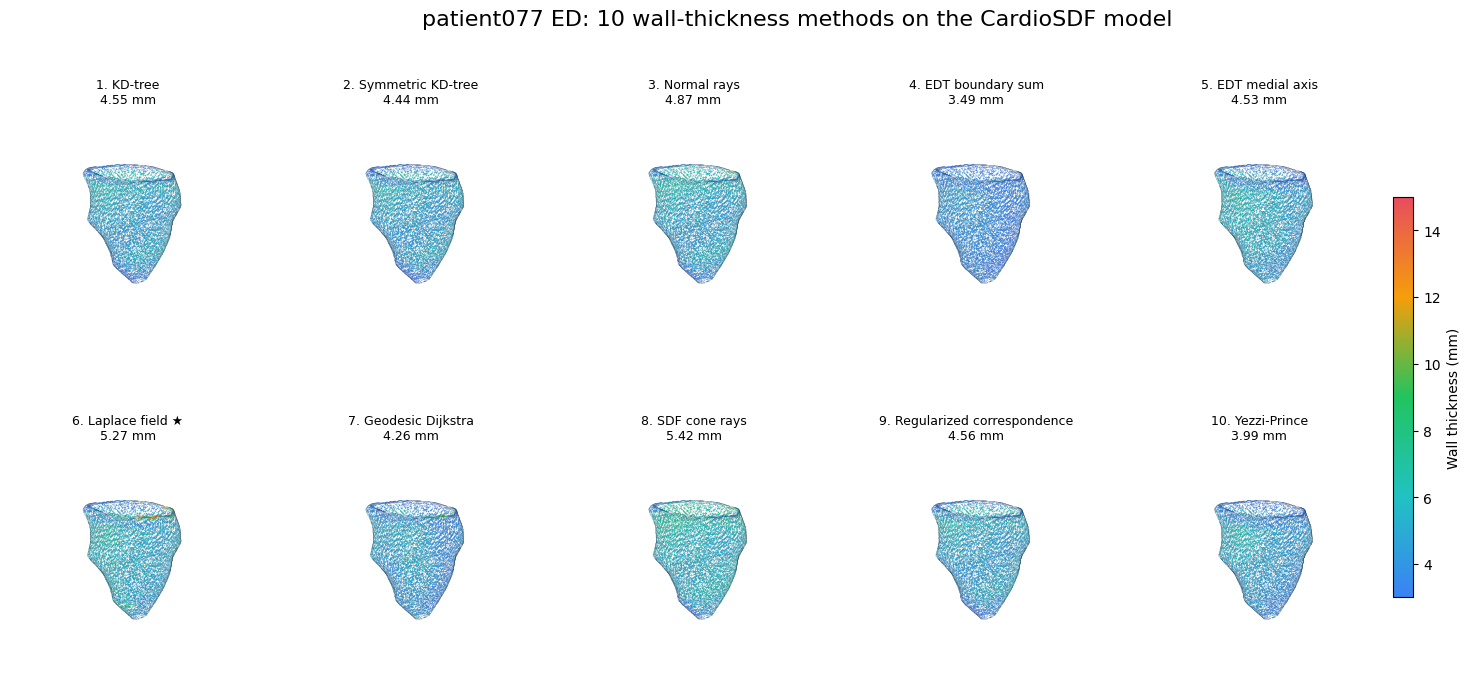

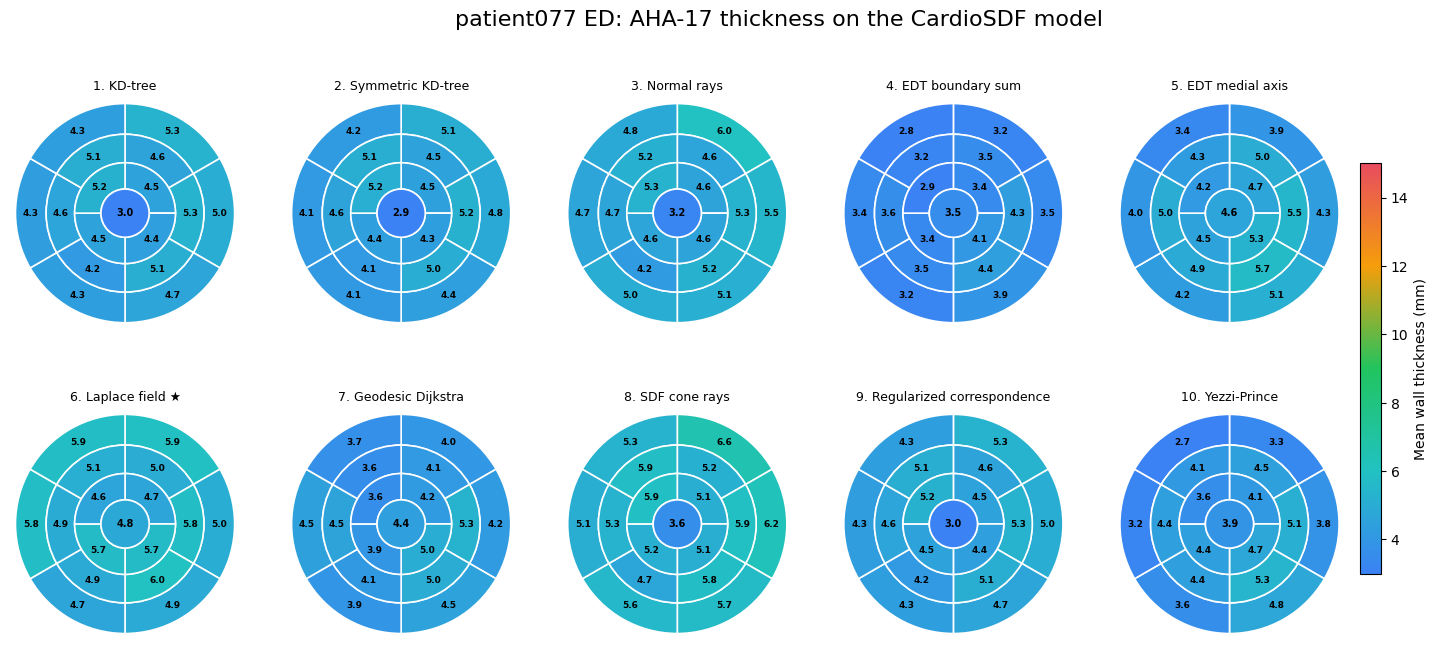

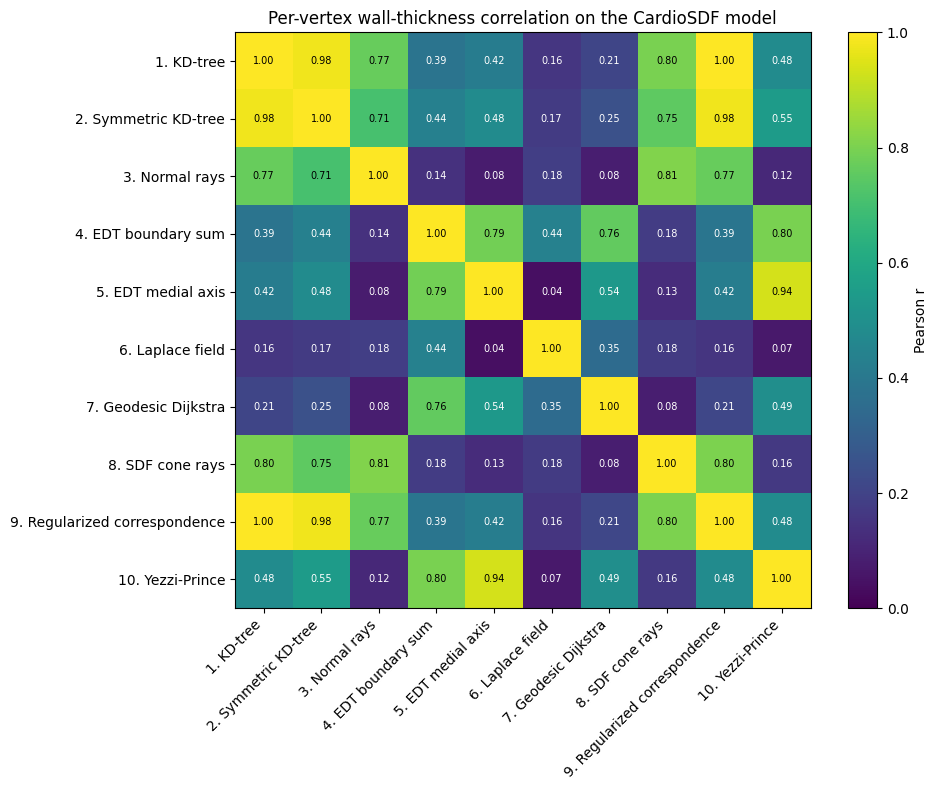

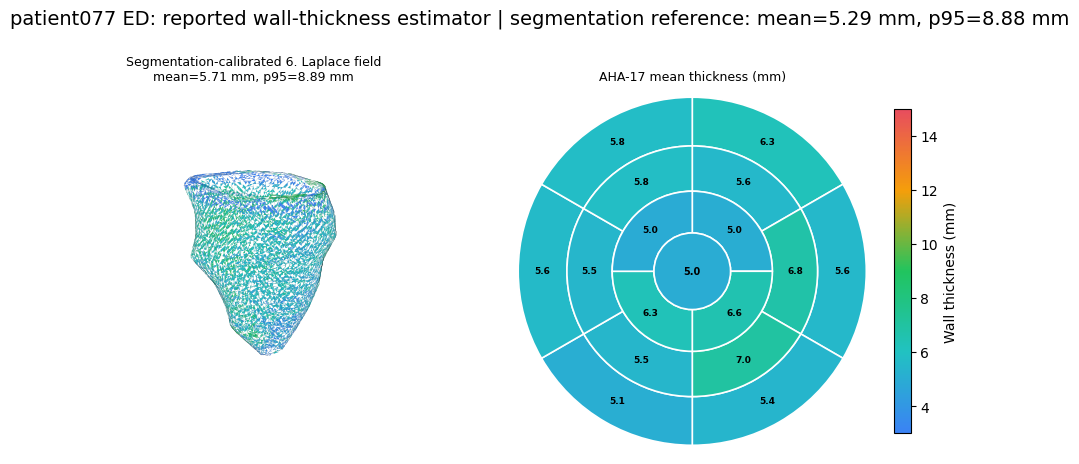

Saved figures:
/home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_on_cardiosdf_model_10_methods_3d.png
/home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_on_cardiosdf_model_10_methods_aha17.png
/home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_on_cardiosdf_model_method_correlations.png
/home/andre/Downloads/tese/webapp/notebooks/outputs/lv_wall_thickness_recommended_thesis_method.png


In [46]:
wt_cmap = mcolors.LinearSegmentedColormap.from_list(
    "webapp_wall_thickness",
    [
        (0.00, (0.23, 0.51, 0.96)),
        (0.25, (0.13, 0.76, 0.76)),
        (0.50, (0.13, 0.77, 0.37)),
        (0.75, (0.96, 0.62, 0.04)),
        (1.00, (0.91, 0.30, 0.37)),
    ],
)
wt_norm = mcolors.Normalize(vmin=CMIN_MM, vmax=CMAX_MM)


def set_axes_equal_3d(ax: plt.Axes, vertices: np.ndarray) -> None:
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    center = (mins + maxs) / 2.0
    radius = float(np.max(maxs - mins) / 2.0)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] + radius, center[2] - radius)  # invert z so base (low z) is at top
    ax.set_axis_off()


def plot_mesh_thickness_panel(ax: plt.Axes, vertices: np.ndarray, faces: np.ndarray, values: np.ndarray, title: str) -> None:
    if len(faces) > 12000:
        step = int(np.ceil(len(faces) / 12000))
        faces_plot = faces[::step]
    else:
        faces_plot = faces
    face_values = np.nanmean(values[faces_plot], axis=1)
    face_values = np.nan_to_num(face_values, nan=np.nanmedian(values[np.isfinite(values)]))
    poly = Poly3DCollection(vertices[faces_plot], linewidths=0.02, alpha=1.0)
    poly.set_facecolor(wt_cmap(wt_norm(face_values)))
    poly.set_edgecolor((0, 0, 0, 0.02))
    ax.add_collection3d(poly)
    ax.view_init(elev=15, azim=-60)
    set_axes_equal_3d(ax, vertices)
    ax.set_title(title, fontsize=9)


def plot_all_3d_maps(results: dict[str, MethodResult]) -> Path:
    n = len(results)
    cols = 5 if n == 10 else min(4, n)
    rows = int(np.ceil(n / cols))
    fig = plt.figure(figsize=(4.2 * cols, 4.0 * rows))
    for i, (name, result) in enumerate(results.items(), start=1):
        ax = fig.add_subplot(rows, cols, i, projection="3d")
        mean = np.nanmean(result.values)
        marker = " ★" if name == globals().get("RECOMMENDED_METHOD") else ""
        title = f"{name}{marker}\n{mean:.2f} mm"
        plot_mesh_thickness_panel(ax, P, F, result.values, title)
    sm = plt.cm.ScalarMappable(norm=wt_norm, cmap=wt_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=fig.axes, shrink=0.65, pad=0.01)
    cbar.set_label("Wall thickness (mm)")
    fig.suptitle(f"{CASE_ID} ED: 10 wall-thickness methods on the CardioSDF model", fontsize=16)
    out = OUTPUT_DIR / "lv_wall_thickness_on_cardiosdf_model_10_methods_3d.png"
    fig.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    return out


def draw_bullseye(ax: plt.Axes, aha_df: pd.DataFrame, title: str) -> None:
    values = {int(row.id): float(row.meanMm) if pd.notna(row.meanMm) else np.nan for row in aha_df.itertuples()}
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=9)
    radii = [1.0, 0.72, 0.46, 0.22, 0.0]
    for r_outer, r_inner, nseg, first_id in [
        (radii[0], radii[1], 6, 1),
        (radii[1], radii[2], 6, 7),
        (radii[2], radii[3], 4, 13),
    ]:
        width_deg = 360.0 / nseg
        for i in range(nseg):
            seg_id = first_id + i
            theta1 = 90.0 - (i + 1) * width_deg
            theta2 = 90.0 - i * width_deg
            val = values.get(seg_id, np.nan)
            color = "#e8ecf1" if not np.isfinite(val) else wt_cmap(wt_norm(val))
            wedge = patches.Wedge((0, 0), r_outer, theta1, theta2, width=r_outer - r_inner,
                                  facecolor=color, edgecolor="white", linewidth=1.2)
            ax.add_patch(wedge)
            ang = math.radians((theta1 + theta2) / 2.0)
            rr = (r_outer + r_inner) / 2.0
            # Show the mean thickness in mm instead of segment number
            label = f"{val:.1f}" if np.isfinite(val) else "—"
            ax.text(rr * math.cos(ang), rr * math.sin(ang), label,
                    ha="center", va="center", fontsize=6.5, fontweight="bold")
    apex = values.get(17, np.nan)
    apex_color = "#e8ecf1" if not np.isfinite(apex) else wt_cmap(wt_norm(apex))
    ax.add_patch(patches.Circle((0, 0), radii[3], facecolor=apex_color, edgecolor="white", linewidth=1.2))
    apex_label = f"{apex:.1f}" if np.isfinite(apex) else "—"
    ax.text(0, 0, apex_label, ha="center", va="center", fontsize=7, fontweight="bold")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)


def plot_all_bullseyes(aha_tables: dict[str, pd.DataFrame]) -> Path:
    n = len(aha_tables)
    cols = 5 if n == 10 else min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.1 * cols, 3.7 * rows))
    axes_arr = np.atleast_1d(axes).ravel()
    for ax, (name, table) in zip(axes_arr, aha_tables.items()):
        marker = " ★" if name == globals().get("RECOMMENDED_METHOD") else ""
        draw_bullseye(ax, table, f"{name}{marker}")
    for ax in axes_arr[len(aha_tables):]:
        ax.axis("off")
    sm = plt.cm.ScalarMappable(norm=wt_norm, cmap=wt_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes_arr.tolist(), shrink=0.72, pad=0.01)
    cbar.set_label("Mean wall thickness (mm)")
    fig.suptitle(f"{CASE_ID} ED: AHA-17 thickness on the CardioSDF model", fontsize=16)
    out = OUTPUT_DIR / "lv_wall_thickness_on_cardiosdf_model_10_methods_aha17.png"
    fig.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    return out


def plot_method_correlations(results: dict[str, MethodResult]) -> Path:
    names = list(results)
    corr = np.full((len(names), len(names)), np.nan, dtype=float)
    for i, n1 in enumerate(names):
        for j, n2 in enumerate(names):
            v1 = results[n1].values
            v2 = results[n2].values
            valid = np.isfinite(v1) & np.isfinite(v2)
            if valid.sum() >= 3:
                corr[i, j] = float(np.corrcoef(v1[valid], v2[valid])[0, 1])
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_xticks(np.arange(len(names)), labels=names, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(names)), labels=names)
    for i in range(len(names)):
        for j in range(len(names)):
            if np.isfinite(corr[i, j]):
                ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="white" if corr[i, j] < 0.55 else "black", fontsize=7)
    fig.colorbar(im, ax=ax, label="Pearson r")
    ax.set_title("Per-vertex wall-thickness correlation on the CardioSDF model")
    fig.tight_layout()
    out = OUTPUT_DIR / "lv_wall_thickness_on_cardiosdf_model_method_correlations.png"
    fig.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    return out


def plot_recommended_report(result: MethodResult, aha_table: pd.DataFrame) -> Path:
    stats = summarize_values(result.values)
    report_label = globals().get("REPORT_METHOD_LABEL", getattr(result, "name", RECOMMENDED_METHOD))
    fig = plt.figure(figsize=(12.5, 5.4))
    ax_mesh = fig.add_subplot(1, 2, 1, projection="3d")
    plot_mesh_thickness_panel(
        ax_mesh,
        P,
        F,
        result.values,
        f"{report_label}\nmean={stats['mean_mm']:.2f} mm, p95={stats['p95_mm']:.2f} mm",
    )
    ax_bull = fig.add_subplot(1, 2, 2)
    draw_bullseye(ax_bull, aha_table, "AHA-17 mean thickness (mm)")
    sm = plt.cm.ScalarMappable(norm=wt_norm, cmap=wt_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_mesh, ax_bull], shrink=0.78, pad=0.02)
    cbar.set_label("Wall thickness (mm)")
    subtitle = ""
    if "reference_mean_mm" in globals() and "reference_p95_mm" in globals():
        subtitle = f" | segmentation reference: mean={reference_mean_mm:.2f} mm, p95={reference_p95_mm:.2f} mm"
    fig.suptitle(
        f"{CASE_ID} ED: reported wall-thickness estimator{subtitle}",
        fontsize=14,
    )
    out = OUTPUT_DIR / "lv_wall_thickness_recommended_thesis_method.png"
    fig.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    return out


if "RECOMMENDED_METHOD" not in globals():
    RECOMMENDED_METHOD = "6. Laplace field" if "6. Laplace field" in results else next(iter(results))
if "REPORT_METHOD_RESULT" not in globals():
    REPORT_METHOD_RESULT = results[RECOMMENDED_METHOD]
if "REPORT_AHA_TABLE" not in globals():
    REPORT_AHA_TABLE = aha_tables[RECOMMENDED_METHOD]
if "REPORT_METHOD_LABEL" not in globals():
    REPORT_METHOD_LABEL = getattr(REPORT_METHOD_RESULT, "name", RECOMMENDED_METHOD)

fig3d_path = plot_all_3d_maps(results)
aha_fig_path = plot_all_bullseyes(aha_tables)
corr_fig_path = plot_method_correlations(results)
recommended_fig_path = plot_recommended_report(REPORT_METHOD_RESULT, REPORT_AHA_TABLE)
print("Saved figures:")
print(fig3d_path)
print(aha_fig_path)
print(corr_fig_path)
print(recommended_fig_path)

## 9. Validation checks

These checks verify method coverage, output shapes, finite fractions, agreement with the webapp's KD-tree baseline from `analyse_segmentation()`, the best raw estimator, and the optional segmentation-calibrated report.

In [47]:
expected_methods = [name for name, _, _ in METHOD_SPECS]
assert list(results.keys()) == expected_methods, "Expected exactly the ten raw wall-thickness methods."
assert len(results) == 10, f"Expected 10 raw methods, found {len(results)}"
assert analysis_geometry_source == "CardioSDF/INR model checkpoint"
assert MODEL_PATH.exists(), "CardioSDF checkpoint is missing."
assert len(P) > 0 and len(Q) > 0 and len(F) > 0, "CardioSDF model geometry is incomplete."
assert myo_mask.any(), "CardioSDF-derived myocardium mask is empty."
assert RECOMMENDED_METHOD in results, "Best raw estimator was not selected."

report_result = globals().get("REPORT_METHOD_RESULT", results[RECOMMENDED_METHOD])
report_label = globals().get("REPORT_METHOD_LABEL", getattr(report_result, "name", RECOMMENDED_METHOD))
assert len(report_result.values) == len(P), "Reported wall-thickness field does not match CardioSDF endocardial vertices."
assert finite_fraction(report_result.values) > 0.85, "Reported wall-thickness field has too many invalid values."

for method_name, result in results.items():
    assert len(result.values) == len(P), f"{method_name}: value count does not match CardioSDF endocardial vertices."
    assert result.valid_fraction > 0.85, f"{method_name}: low valid fraction ({result.valid_fraction:.1%})."

baseline = analyse_segmentation(seg, spacing, source="Input segmentation reference only")
baseline_mean = baseline["metrics"]["meanWallThicknessMm"]
kdtree_mean = float(np.nanmean(results["1. KD-tree"].values))
recommended_mean = float(np.nanmean(results[RECOMMENDED_METHOD].values))
report_mean = float(np.nanmean(report_result.values))
report_p95 = float(np.nanpercentile(report_result.values, 95))
calibration_enabled = bool(globals().get("USE_SEGMENTATION_CALIBRATED_REPORT", False)) and report_label != RECOMMENDED_METHOD

print(f"Analysis geometry: {analysis_geometry_source}")
print(f"CardioSDF checkpoint: {MODEL_PATH}")
print(f"CardioSDF native output metrics: {cardiosdf_output['metrics']}")
print(f"Input-segmentation webapp KD mean (reference only): {baseline_mean:.2f} mm")
print(f"Method 1 KD-tree on CardioSDF model: {kdtree_mean:.2f} mm")
print(f"Best raw thesis estimator: {RECOMMENDED_METHOD} ({recommended_mean:.2f} mm mean)")
print(f"Reported estimator: {report_label} ({report_mean:.2f} mm mean, {report_p95:.2f} mm p95)")

validation_notes: list[str] = [
    "The ten raw estimators are applied to the CardioSDF-generated 3D model surfaces, not to a segmentation marching-cubes mesh.",
    "The input segmentation is used to extract model contours, orient AHA-17 anatomy, and validate estimator plausibility.",
    "The webapp/CardioSDF native KD metric is a nearest-surface lower bound and can underestimate anatomical wall thickness.",
    f"Best raw estimator on this case: {RECOMMENDED_METHOD}.",
]
if calibration_enabled:
    validation_notes.append(
        f"Reported estimator uses segmentation-calibrated post-processing ({report_label}); describe it as calibrated post-processing, not pure CardioSDF inference."
    )
    if "calibrated_epi_shell_path" in globals():
        validation_notes.append(f"A surrogate epicardial shell expanded along outward normals was exported to {calibrated_epi_shell_path}.")
else:
    validation_notes.append(f"For thesis reporting on this case, use {RECOMMENDED_METHOD}: it is the raw CardioSDF-surface estimator with the closest mean/p95 agreement to the input-segmentation reference.")

for note in validation_notes:
    print("NOTE:", note)

# AHA anatomical QA checks on CardioSDF model vertices.
counts = np.array([aha_diag["segment_counts"][i] for i in range(1, 18)])
assert counts.sum() == len(P), "AHA assignment does not cover all CardioSDF model vertices."
assert counts[:16].min() > 0, "At least one non-apex AHA segment has no vertices; inspect orientation/levels."
assert aha_diag["base_slice"] != aha_diag["apex_slice"], "Base/apex detection collapsed to one slice."
print("AHA base slice:", aha_diag["base_slice"], "apex slice:", aha_diag["apex_slice"])
print("Raw z direction:", "base→apex increases with z" if aha_diag["z_sign_base_to_apex"] > 0 else "base→apex decreases with z")
print("RV angle from anterior should be near the septal sector (around 90°):", aha_diag["rv_angle_from_anterior_deg"])

validation_report = {
    "analysis_geometry_source": analysis_geometry_source,
    "cardiosdf_checkpoint": str(MODEL_PATH),
    "cardiosdf_grid_res": CARDIOSDF_GRID_RES,
    "cardiosdf_native_metrics": cardiosdf_output["metrics"],
    "cardiosdf_mask_diagnostics": cardiosdf_mask_diag,
    "input_segmentation_reference_kdtree_mean_mm": float(baseline_mean),
    "input_segmentation_reference_mc_mean_mm": float(reference_mean_mm),
    "input_segmentation_reference_mc_p95_mm": float(reference_p95_mm),
    "method1_kdtree_on_cardiosdf_model_mm": kdtree_mean,
    "best_raw_method": RECOMMENDED_METHOD,
    "best_raw_method_mean_mm": recommended_mean,
    "reported_method": report_label,
    "reported_method_mean_mm": report_mean,
    "reported_method_p95_mm": report_p95,
    "segmentation_calibrated_report_enabled": calibration_enabled,
    "calibration_base_method": globals().get("CALIBRATION_BASE_METHOD"),
    "calibration_min_reference_mm": globals().get("CALIBRATION_MIN_REFERENCE_MM"),
    "calibrated_surrogate_shell": str(globals().get("calibrated_epi_shell_path")) if "calibrated_epi_shell_path" in globals() else None,
    "notes": validation_notes,
    "aha_base_slice": int(aha_diag["base_slice"]),
    "aha_apex_slice": int(aha_diag["apex_slice"]),
    "aha_rv_angle_from_anterior_deg": aha_diag["rv_angle_from_anterior_deg"],
}
validation_path = OUTPUT_DIR / "lv_wall_thickness_validation_report.json"
validation_path.write_text(json.dumps(validation_report, indent=2))
print(f"Saved validation report to {validation_path}")
print("Validation checks passed.")

Analysis geometry: CardioSDF/INR model checkpoint
CardioSDF checkpoint: /home/andre/Downloads/tese/webapp/model/inr_sdf_combined_fresh_ed_mix_v1_final.ptrom
CardioSDF native output metrics: {'meanWallThicknessMm': 4.54, 'p95WallThicknessMm': 6.18, 'endoSurfaceAreaCm2': 91.0, 'epiSurfaceAreaCm2': 126.58, 'gridResolution': 72, 'endoVertices': 13072, 'epiVertices': 17902}
Input-segmentation webapp KD mean (reference only): 3.61 mm
Method 1 KD-tree on CardioSDF model: 4.55 mm
Best raw thesis estimator: 6. Laplace field (5.27 mm mean)
Reported estimator: Segmentation-calibrated 6. Laplace field (5.71 mm mean, 8.89 mm p95)
NOTE: The ten raw estimators are applied to the CardioSDF-generated 3D model surfaces, not to a segmentation marching-cubes mesh.
NOTE: The input segmentation is used to extract model contours, orient AHA-17 anatomy, and validate estimator plausibility.
NOTE: The webapp/CardioSDF native KD metric is a nearest-surface lower bound and can underestimate anatomical wall thickn

## 10. Optional: export colored meshes

This exports one colored PLY per raw method. The colors use the same 3--15 mm wall-thickness scale as the figures. The segmentation-calibrated surrogate epicardial shell from Section 7 is exported automatically when calibration is enabled.

In [48]:
EXPORT_COLORED_MESHES = False


def colors_for_values(values: np.ndarray) -> np.ndarray:
    finite = np.isfinite(values)
    fallback = np.nanmedian(values[finite]) if finite.any() else CMIN_MM
    rgba = wt_cmap(wt_norm(np.nan_to_num(values, nan=fallback)))
    return (rgba[:, :4] * 255).astype(np.uint8)


if EXPORT_COLORED_MESHES:
    mesh_dir = OUTPUT_DIR / "colored_meshes"
    mesh_dir.mkdir(parents=True, exist_ok=True)
    for method_name, result in results.items():
        mesh = trimesh.Trimesh(vertices=P, faces=F, process=False)
        mesh.visual = trimesh.visual.ColorVisuals(mesh=mesh, vertex_colors=colors_for_values(result.values))
        safe_name = method_name.lower().replace(" ", "_").replace(".", "").replace("/", "_")
        out_path = mesh_dir / f"{safe_name}_on_cardiosdf_model.ply"
        mesh.export(out_path)
        print(out_path)
else:
    print("Set EXPORT_COLORED_MESHES=True to export colored CardioSDF-model PLY meshes for each method.")

Set EXPORT_COLORED_MESHES=True to export colored CardioSDF-model PLY meshes for each method.
